In [1]:
## mirtud_env (R kernel)
## This notebook plots all figs from the saved data frames

In [1]:
suppressWarnings(library(ggplot2))
suppressWarnings(library(ggpubr))
suppressWarnings(library(ggrepel))
suppressWarnings(library(dplyr))
suppressWarnings(library(tidyr))
suppressWarnings(library(gridExtra))
suppressWarnings(library(cowplot))
suppressWarnings(library(patchwork))
suppressWarnings(library(stringr))
suppressWarnings(library(igraph))
suppressWarnings(library(ggforce))
suppressWarnings(library(ComplexHeatmap))

major_text_size = 8
minor_text_size = 6.5
lnwidth = 0.694
path = '/home/ssobti/projects/heterogeneity_brian/'

## Addition to all plots at the end to centralize fonts and borders:
# + theme(margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots



Attaching package: ‘igraph’


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: grid

ComplexHeatmap version 2.2.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https

## Fig 1 ##

### CO zscores boxplot ###

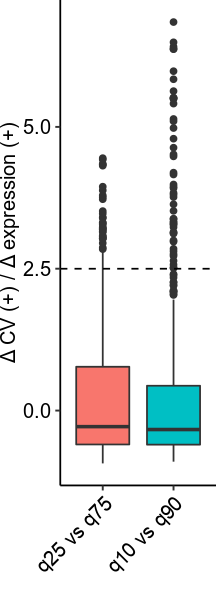

In [2]:
wfix = 1.8
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)

## value column is z-score
z_melt_ordered_q75 = read.csv('/home/ssobti/projects/heterogeneity_brian/output_data/TCGA_nb_analysis/nb_pause_points/TCGA_breast_q25_q75_original/z_melt_ordered_q25_q75.csv')
z_melt_ordered_q90 = read.csv('/home/ssobti/projects/heterogeneity_brian/output_data/TCGA_nb_analysis/nb_pause_points/TCGA_breast_q10_q90_original/z_melt_ordered_q10_q90.csv')
z_melt_ordered = bind_rows('q25 vs q75' = z_melt_ordered_q75, 'q10 vs q90' = z_melt_ordered_q90, .id = 'group')
z_melt_ordered = z_melt_ordered %>% select(-X)
z_melt_ordered$group <- factor(z_melt_ordered$group, levels = c('q25 vs q75', 'q10 vs q90'))
saveRDS(z_melt_ordered, paste0(path, 'fig_output/data/fig1/CO_zscores_boxplot.rds'))

ggplot(z_melt_ordered, mapping = aes(x = group, y = value, fill = group)) + 
geom_boxplot(show.legend = F) + scale_fill_discrete() + geom_hline(yintercept = 2.5, linetype = 'dashed', color = 'black') +
xlab('') + ylab('\u0394 CV (+) / \u0394 expression (+)') + theme_pubr() + theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig1/CO_zscores_boxplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### CO PCA distances sinaplot ###

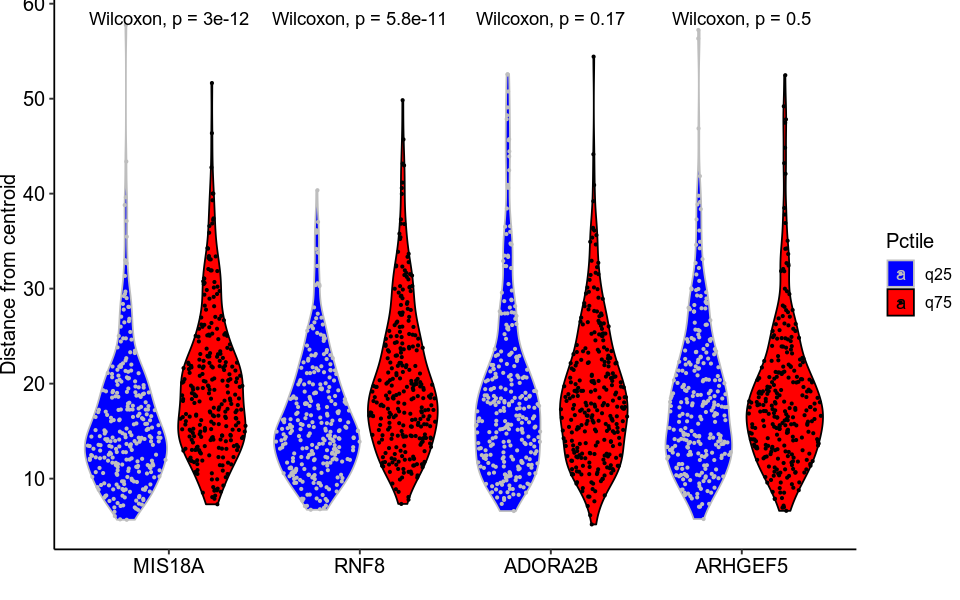

In [80]:
wfix = 8
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)

PCA_q25_q75_sina_df_select = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/PCA_q25_q75_sina_df_select.rds')

ggplot(PCA_q25_q75_sina_df_select, aes(Grouping_gene, Distance_from_centroid, color = Pctile, fill = Pctile)) +
  geom_violin(position=position_dodge()) +
  geom_sina(position=position_dodge(), size = 0.5)+ scale_color_manual(values = c('grey', 'black')) + scale_fill_manual(values = c('blue', 'red')) + stat_compare_means(method = 'wilcox') +
  theme_pubr() + theme(plot.title = element_text(hjust = 0.5), legend.position = 'right') + xlab('') + ylab('Distance from centroid') +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig1/CO_PCA_distances_select_sinaplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

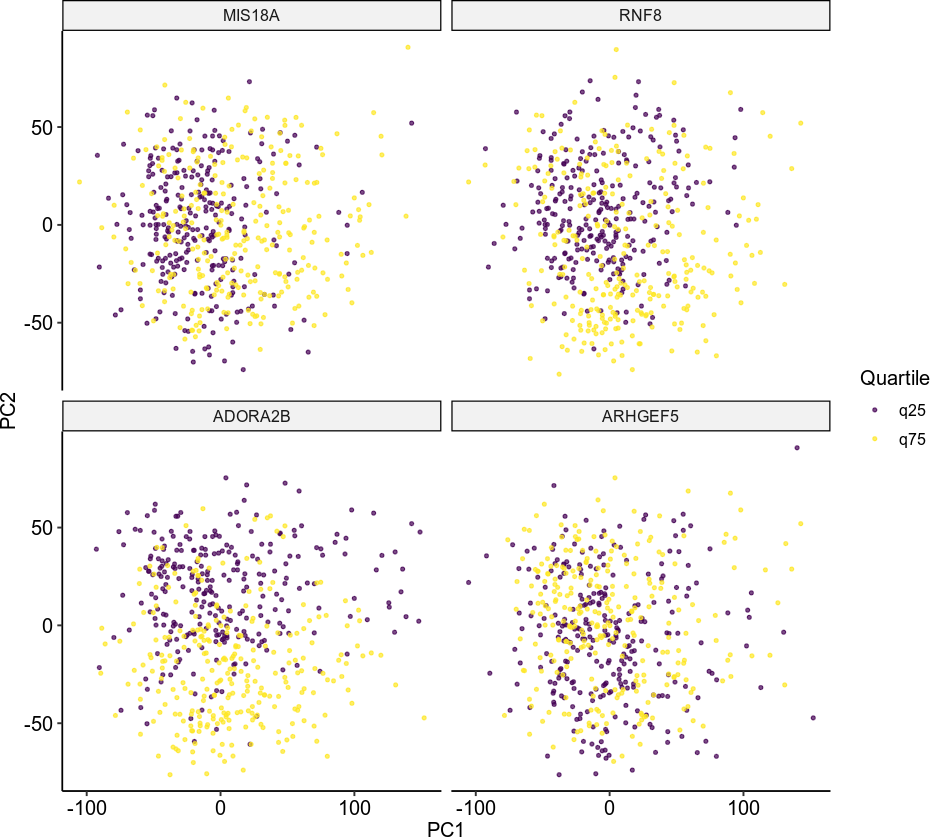

In [92]:
wfix = 7.85
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)

q25_q75_PCA_df_select = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/q25_q75_PCA_df_select.rds')

ggplot(q25_q75_PCA_df_select, aes(PC1, PC2, color = Quartile)) + geom_point(alpha = 0.7, size = 0.8) + scale_color_viridis_d() + facet_wrap(~Grouping_gene) + theme_pubr() + theme(legend.position = 'right') +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig1/CO_PCA_distances_select_pcaplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### CV and mean density plots ###

In [2]:
wfix = 7.85
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_CVs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_RNF8_CVs.rds')
MIS18A_CVs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_MIS18A_CVs.rds')
RNF8_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_RNF8_means.rds')
MIS18A_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_MIS18A_means.rds')
adj_pvals_cvs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_adj_pvals_cvs.rds')
adj_pvals_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_adj_pvals_means.rds')

In [3]:
head(RNF8_CVs)

genes,Quantile,CV
<fct>,<chr>,<dbl>
LOC100130426,q25,7.7635738
LOC100130426,q75,7.5980386
UBE2Q2P3,q25,0.7981112
UBE2Q2P3,q75,1.0162170
UBE2Q2P3,q25,0.7372859
UBE2Q2P3,q75,0.8195021


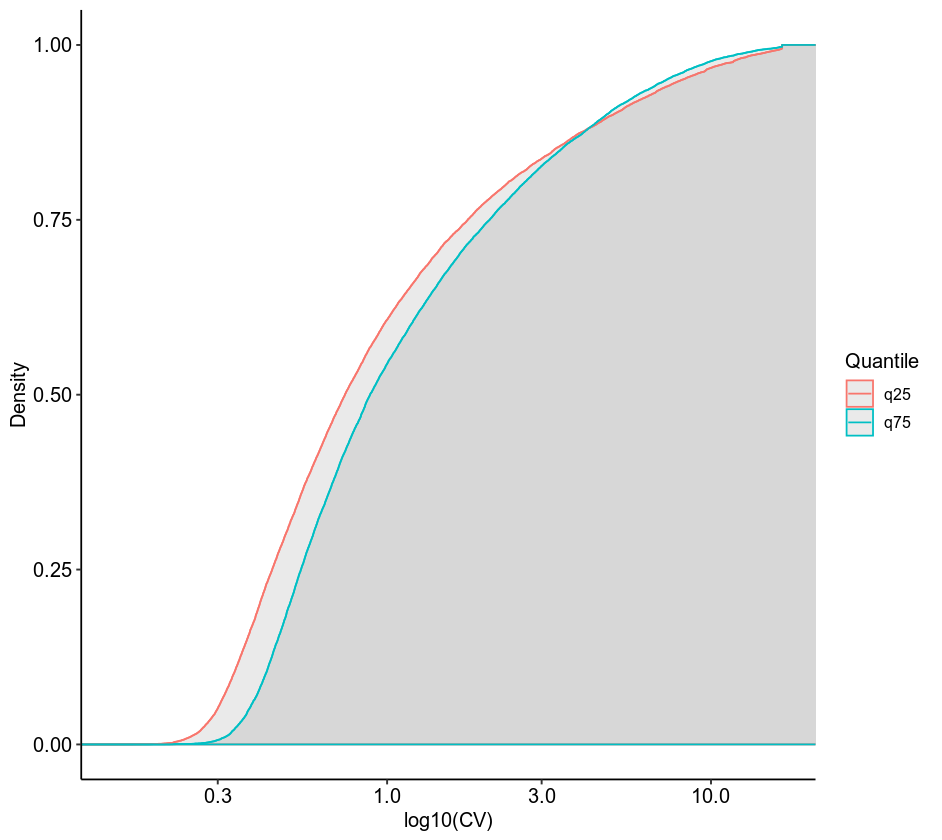

In [24]:
ggplot(RNF8_CVs, aes(CV, colour = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) +
  stat_ecdf(geom = 'step') + scale_x_continuous(trans = 'log10') + theme_pubr() + theme(legend.position = 'right') + xlab('log10(CV)') + ylab('Density')

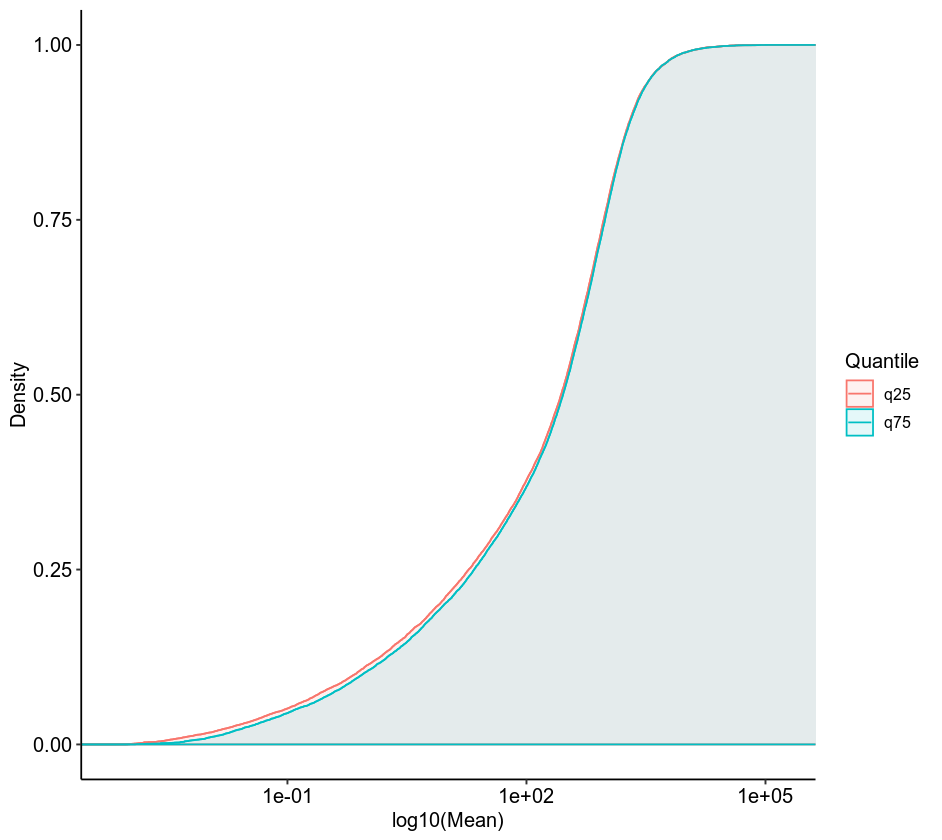

In [ ]:
ggplot(RNF8_means, aes(mean, colour = Quantile, fill = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) +
  stat_ecdf(geom = 'step') + scale_x_continuous(trans = 'log10') + theme_pubr() + theme(legend.position = 'right') + xlab('log10(Mean)') + ylab('Density')

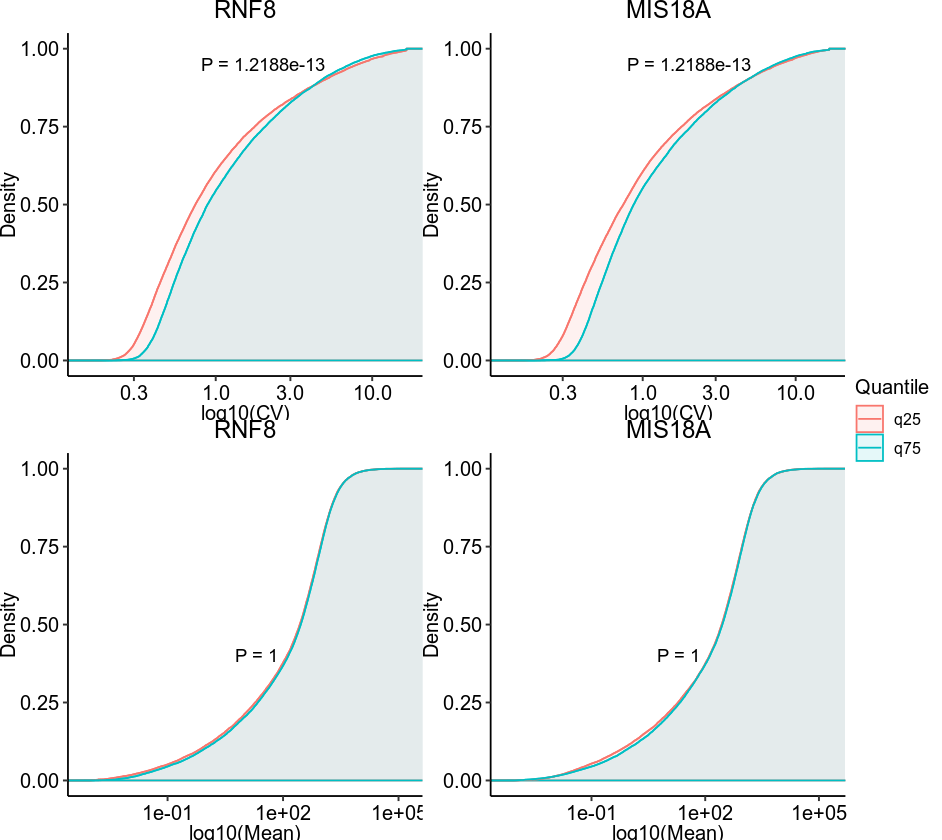

In [29]:
wfix = 7.85
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_CVs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_RNF8_CVs.rds')
MIS18A_CVs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_MIS18A_CVs.rds')
RNF8_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_RNF8_means.rds')
MIS18A_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_MIS18A_means.rds')
adj_pvals_cvs = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_adj_pvals_cvs.rds')
adj_pvals_means = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/density_adj_pvals_means.rds')

pl1 = RNF8_CVs %>%
    ggplot(aes(x = CV, fill = Quantile, color = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) + stat_ecdf(geom = 'step') + xlab('log10(CV)') + ylab('Density') + ggtitle('RNF8') +
    scale_x_continuous(trans = 'log10') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) + annotate('text', x = 2, y = 0.95, label = paste0('P = ', adj_pvals_cvs[['RNF8']])) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

pl2 = MIS18A_CVs %>%
    ggplot(aes(x = CV, fill = Quantile, color = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) + stat_ecdf(geom = 'step') + xlab('log10(CV)') + ylab('Density') + ggtitle('MIS18A') +
    scale_x_continuous(trans = 'log10') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) + annotate('text', x = 2, y = 0.95, label = paste0('P = ', adj_pvals_cvs[['MIS18A']])) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

pl3 = RNF8_means %>%
    ggplot(aes(x = mean, fill = Quantile, color = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) + stat_ecdf(geom = 'step') + xlab('log10(Mean)') + ylab('Density') + ggtitle('RNF8') +
    scale_x_continuous(trans = 'log10') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) + annotate('text', x = 20, y = 0.4, label = paste0('P = ', adj_pvals_means[['RNF8']])) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

pl4 = MIS18A_means %>%
    ggplot(aes(x = mean, fill = Quantile, color = Quantile)) + stat_ecdf(aes(ymin = 0, ymax= ..y..), geom = 'ribbon', alpha = 0.1) + stat_ecdf(geom = 'step') + xlab('log10(Mean)') + ylab('Density') + ggtitle('MIS18A') + 
    scale_x_continuous(trans = 'log10') + theme_pubr() + theme(plot.title = element_text(hjust = 0.5)) + annotate('text', x = 20, y = 0.4, label = paste0('P = ', adj_pvals_means[['MIS18A']])) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(pl1, pl2, pl3, pl4, ncol = 2, nrow = 2, common.legend = T, legend = 'right')

ggsave(paste0(path, 'fig_output/data/fig1/CV_mean_density_plots.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### Correlation between gene exp CV and CNA CV ###

Warning message:
“Removed 119 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 119 rows containing non-finite values (stat_cor).”
Warning message:
“Removed 119 rows containing missing values (geom_point).”
Warning message:
“Removed 199 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 199 rows containing non-finite values (stat_cor).”
Warning message:
“Removed 199 rows containing missing values (geom_point).”


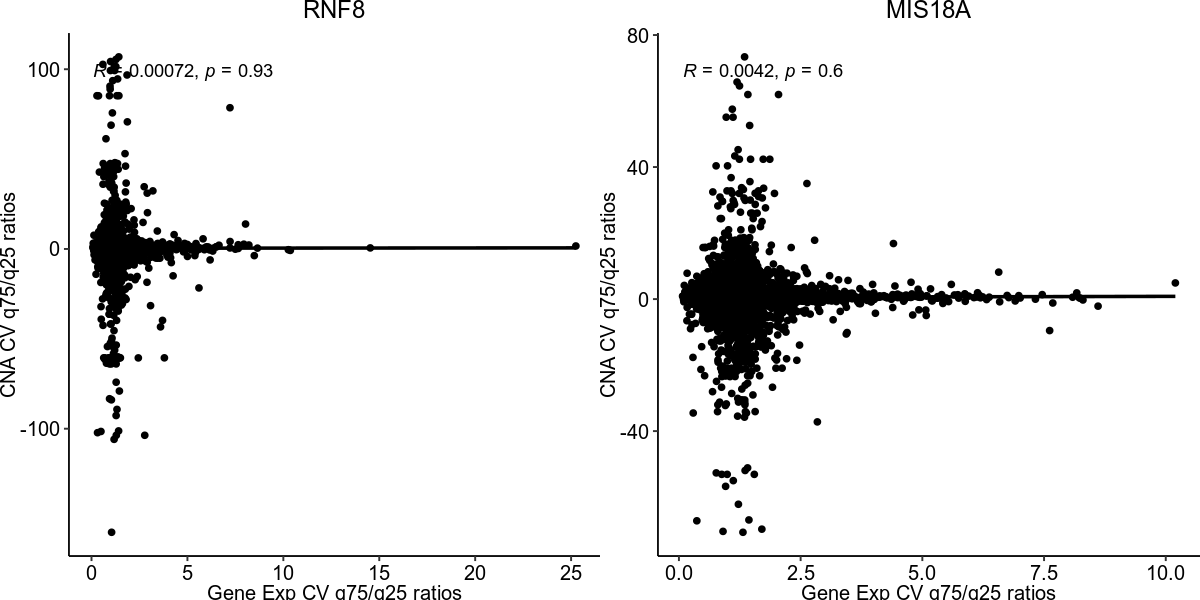

In [75]:
## q25 vs q75 ##
wfix = 10
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
RNF8_corr_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/RNF8_corr_df_q25_q75.RDS')
MIS18A_corr_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/MIS18A_corr_df_q25_q75.RDS')

pl1 = RNF8_corr_df %>% ggplot(aes(x = gene_exp_CV_ratios, y = CNA_CV_ratios)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('Gene Exp CV q75/q25 ratios') + ylab('CNA CV q75/q25 ratios') +
    stat_cor(aes(), method = "pearson") + theme_pubr() +  
    ggtitle('RNF8') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

pl2 = MIS18A_corr_df %>% ggplot(aes(x = gene_exp_CV_ratios, y = CNA_CV_ratios)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('Gene Exp CV q75/q25 ratios') + ylab('CNA CV q75/q25 ratios') +
    stat_cor(aes(), method = "pearson") + theme_pubr() +  
    ggtitle('MIS18A') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(pl1, pl2, ncol = 2, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig1/gene_exp_CNA_corr_q25_q75_scatter.pdf'), width = wfix, height = hfix, device = cairo_pdf)

Warning message:
“Removed 292 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 292 rows containing non-finite values (stat_cor).”
Warning message:
“Removed 292 rows containing missing values (geom_point).”
Warning message:
“Removed 516 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 516 rows containing non-finite values (stat_cor).”
Warning message:
“Removed 516 rows containing missing values (geom_point).”


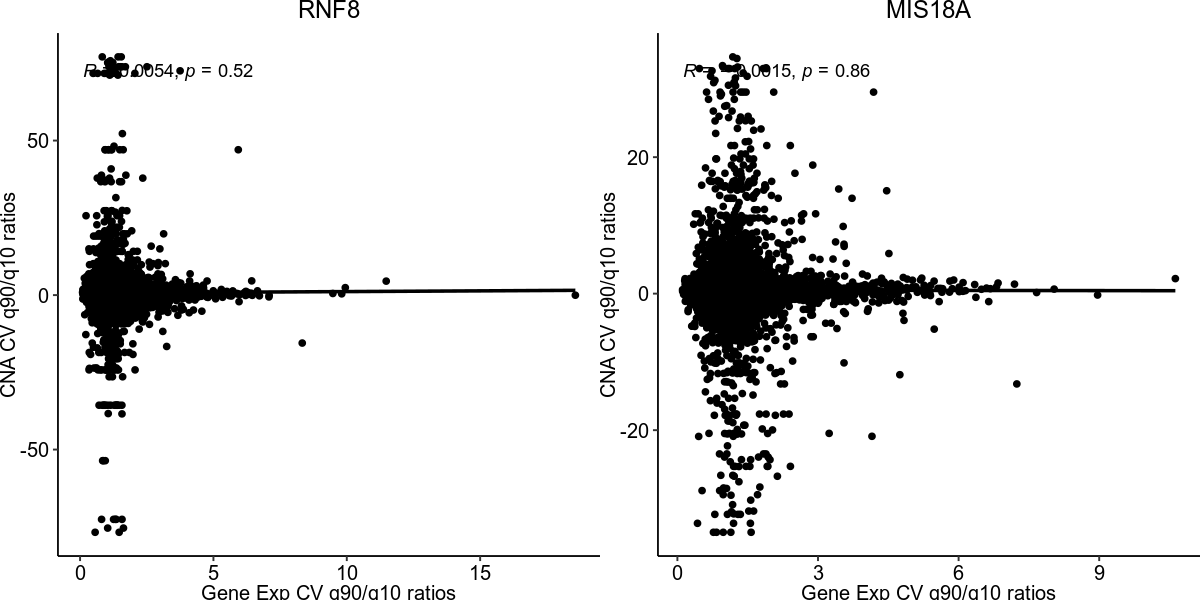

In [77]:
## q10 vs q90 ##
wfix = 10
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)
RNF8_corr_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/RNF8_corr_df_q10_q90.RDS')
MIS18A_corr_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/MIS18A_corr_df_q10_q90.RDS')

pl1 = RNF8_corr_df %>% ggplot(aes(x = gene_exp_CV_ratios, y = CNA_CV_ratios)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('Gene Exp CV q90/q10 ratios') + ylab('CNA CV q90/q10 ratios') +
    stat_cor(aes(), method = "pearson") + theme_pubr() +  
    ggtitle('RNF8') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

pl2 = MIS18A_corr_df %>% ggplot(aes(x = gene_exp_CV_ratios, y = CNA_CV_ratios)) +
    geom_smooth(method = "lm", formula = y ~ x, se = F, color = 'black') + geom_point() + xlab('Gene Exp CV q90/q10 ratios') + ylab('CNA CV q90/q10 ratios') +
    stat_cor(aes(), method = "pearson") + theme_pubr() +  
    ggtitle('MIS18A') + #ylim(-0.32, 0.32) + xlim(-0.32, 0.32) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(pl1, pl2, ncol = 2, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig1/gene_exp_CNA_corr_q10_q90_scatter.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### ESTIMATE Tumor Purity boxplots ###

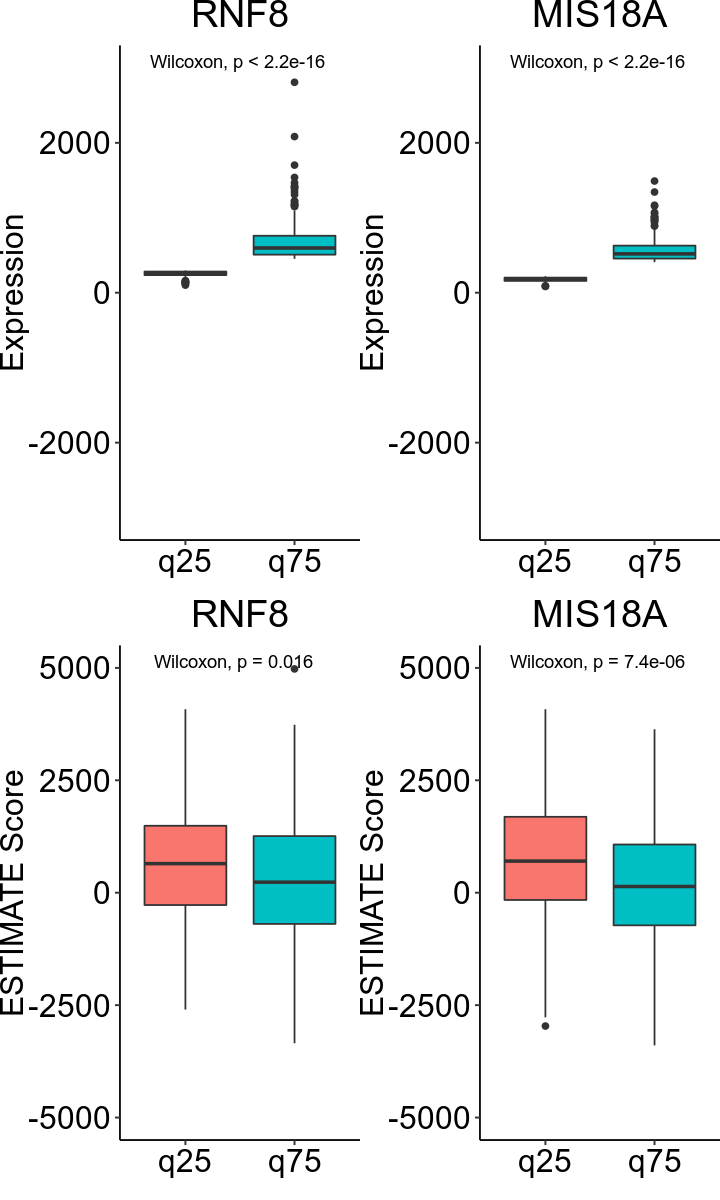

In [26]:
## q25 vs q75 ##
wfix = 6
hfix = 10
options(repr.plot.width = wfix, repr.plot.height = hfix)
ESTIMATE_scores_w_CO_exp_and_quantiles = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig1/ESTIMATE_scores_w_CO_exp_and_quantiles_q25_q75.rds')

plot1 = ESTIMATE_scores_w_CO_exp_and_quantiles %>% dplyr::filter(RNF8_q25_q75_quantile != 'neither') %>% select(RNF8_exp, ESTIMATE_score, RNF8_q25_q75_quantile) %>% pivot_longer(cols = -RNF8_q25_q75_quantile, names_to = 'score', values_to = 'value') %>% mutate(score = factor(score, levels = c('RNF8_exp', 'ESTIMATE_score'))) %>% filter(score != 'ESTIMATE_score') %>% ggplot(aes(x = RNF8_q25_q75_quantile, y = value, fill = RNF8_q25_q75_quantile)) + geom_boxplot(show.legend = F) + theme_pubr() + theme(text = element_text(size = 19), plot.title = element_text(hjust = 0.5)) + ggtitle('RNF8') + ylim(-3000, 3000) + stat_compare_means(method = 'wilcox') + guides(fill = guide_legend(title = "Quantile")) + xlab('') + ylab('Expression') + 
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plot2 = ESTIMATE_scores_w_CO_exp_and_quantiles %>% dplyr::filter(MIS18A_q25_q75_quantile != 'neither') %>% select(MIS18A_exp, ESTIMATE_score, MIS18A_q25_q75_quantile) %>% pivot_longer(cols = -MIS18A_q25_q75_quantile, names_to = 'score', values_to = 'value') %>% mutate(score = factor(score, levels = c('MIS18A_exp', 'ESTIMATE_score'))) %>% filter(score != 'ESTIMATE_score') %>% ggplot(aes(x = MIS18A_q25_q75_quantile, y = value, fill = MIS18A_q25_q75_quantile)) + geom_boxplot(show.legend = F) + theme_pubr() + theme(text = element_text(size = 19), plot.title = element_text(hjust = 0.5)) + ggtitle('MIS18A') + ylim(-3000, 3000) + stat_compare_means(method = 'wilcox') + guides(fill = guide_legend(title = "Quantile")) + xlab('') + ylab('Expression') +
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))


plot3 = ESTIMATE_scores_w_CO_exp_and_quantiles %>% dplyr::filter(RNF8_q25_q75_quantile != 'neither') %>% select(RNF8_exp, ESTIMATE_score, RNF8_q25_q75_quantile) %>% pivot_longer(cols = -RNF8_q25_q75_quantile, names_to = 'score', values_to = 'value') %>% mutate(score = factor(score, levels = c('RNF8_exp', 'ESTIMATE_score'))) %>% filter(score == 'ESTIMATE_score') %>% ggplot(aes(x = RNF8_q25_q75_quantile, y = value, fill = RNF8_q25_q75_quantile)) + geom_boxplot(show.legend = F) + theme_pubr() + theme(text = element_text(size = 19), plot.title = element_text(hjust = 0.5)) + ggtitle('RNF8') + ylim(-5000, 5000) + stat_compare_means(method = 'wilcox') + guides(fill = guide_legend(title = "Quantile")) + xlab('') + ylab('ESTIMATE Score') + 
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plot4 = ESTIMATE_scores_w_CO_exp_and_quantiles %>% dplyr::filter(MIS18A_q25_q75_quantile != 'neither') %>% select(MIS18A_exp, ESTIMATE_score, MIS18A_q25_q75_quantile) %>% pivot_longer(cols = -MIS18A_q25_q75_quantile, names_to = 'score', values_to = 'value') %>% mutate(score = factor(score, levels = c('MIS18A_exp', 'ESTIMATE_score'))) %>% filter(score == 'ESTIMATE_score') %>% ggplot(aes(x = MIS18A_q25_q75_quantile, y = value, fill = MIS18A_q25_q75_quantile)) + geom_boxplot(show.legend = F) + theme_pubr() + theme(text = element_text(size = 19), plot.title = element_text(hjust = 0.5)) + ggtitle('MIS18A') + ylim(-5000, 5000) + stat_compare_means(method = 'wilcox') + guides(fill = guide_legend(title = "Quantile")) + xlab('') + ylab('ESTIMATE Score') +
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))
ggarrange(plot1, plot2, plot3, plot4, ncol = 2, nrow = 2)

ggsave(paste0(path, 'fig_output/data/fig1/ESTIMATE_scores_w_CO_exp_and_quantiles_q25_q75.pdf'), width = wfix, height = hfix, device = cairo_pdf)



## Fig 2 ##

### [Plot name] ###

## Fig 3 ##


### Single cell guide CV ratios violin plots ###

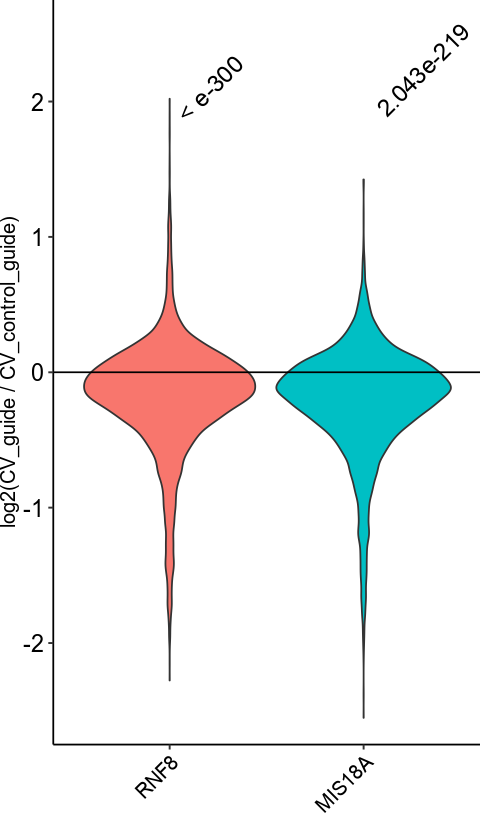

In [30]:
## CRISPRi ##
wfix = 4
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_violin_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_pvals.rds')
ratios_df %>% dplyr::filter(guide %in% c('MIS18A', 'RNF8')) %>% mutate(guide = factor(guide, levels = c('RNF8', 'MIS18A'))) %>% ggplot(aes(guide, CV_gdCV_ctrlratio, fill = guide)) + ylab('log2(CV_guide / CV_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:2, y = 1.8, size = 5, angle='45', hjust = -0.2, label = pvals_adj[1:2]) + xlab('') +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off', ylim = c(-2.5,2.5)) +
  theme_pubr() + theme(plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1))  +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispri_single_cell_violin_CVs_select.pdf'), width = wfix, height = hfix, device = cairo_pdf)

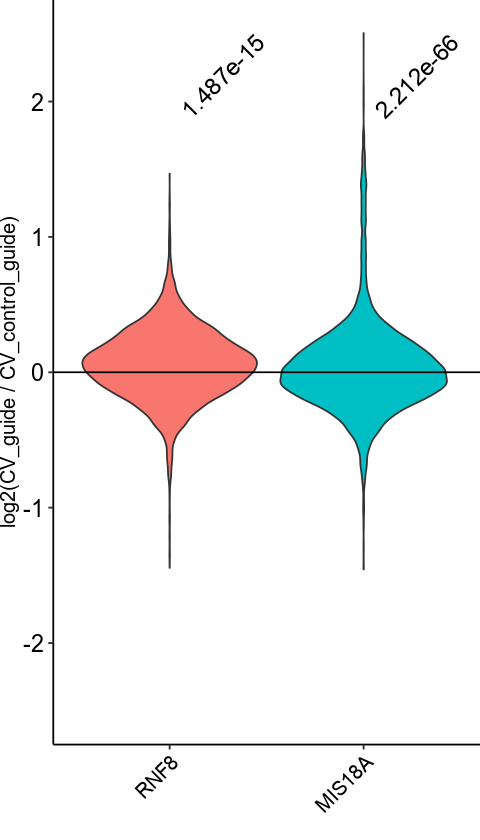

In [29]:
## CRISPRa ##
wfix = 4
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)
ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_violin_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_pvals.rds')

ratios_df %>% dplyr::filter(guide %in% c('MIS18A', 'RNF8')) %>% mutate(guide = factor(guide, levels = c('RNF8', 'MIS18A'))) %>% ggplot(aes(guide, CV_gdCV_ctrlratio, fill = guide)) + ylab('log2(CV_guide / CV_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:2, y = 1.8, size = 5, angle='45', hjust = -0.2, label = pvals_adj[c(length(pvals_adj)-2, length(pvals_adj))]) +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off', ylim = c(-2.5,2.5)) + xlab('') +
  theme_pubr() + theme(plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispra_single_cell_violin_CVs_select.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### CRISPRi plots ###

[1] "Percent genes with lower CV than control (top half): 68.96 %"

[1] "Percent genes with higher CV than control (bottom half): 31.04 %"

[1] "Mean CV (control): 1.09675060248231"

[1] "Mean CV (RNF8): 0.952551162546552"

[1] "P-value paired t-test: 1.09e-135"

png 
  2

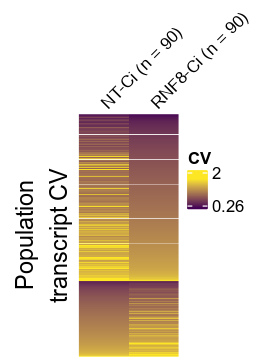

In [5]:
## RNF8 CRISPRi ##
wfix = 2.2
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ci_CV_htmp_df.rds')
lower_RNF8 = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ci_CV_lower.rds')
upper_RNF8 = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ci_CV_upper.rds')

set.seed(20)
coloring_map <- circlize::colorRamp2(c(0.26, 1.6), scales::viridis_pal(option = 'D')(5)[c(1,5)])

perturb_perturb_corr_mtx_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = TRUE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = 'Population\ntranscript CV', 
              row_title_side = 'left', column_title_side = 'top', column_names_side = 'top',
               column_names_gp = gpar(fontsize = 10), row_names_gp = gpar(fontsize = 1), column_names_rot = 45,
               cluster_rows = FALSE, cluster_columns = FALSE, heatmap_legend_param = list(title = "CV", at = c(0.26, 2))), padding = unit(c(2, 2, 2, 12), "pt"))
}


paste('Percent genes with lower CV than control (top half):', round(100*nrow(lower_RNF8)/nrow(RNF8_Ci_df), 2), '%')
paste('Percent genes with higher CV than control (bottom half):', round(100*nrow(upper_RNF8)/nrow(RNF8_Ci_df), 2), '%')
paste('Mean CV (control):', mean(RNF8_Ci_df[,1]))
paste('Mean CV (RNF8):', mean(RNF8_Ci_df[,2]))
paste('P-value paired t-test:', signif(t.test(RNF8_Ci_df[,1], RNF8_Ci_df[,2], paired = TRUE)$p.value, 3))

perturb_perturb_corr_mtx_htmp(RNF8_Ci_df)

pdf(paste0(path, 'fig_output/data/fig3/crispri_rnf8_single_cell_htmp_CVs_select.pdf'), width = wfix, height = hfix)
perturb_perturb_corr_mtx_htmp(RNF8_Ci_df)
dev.off()

Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Arial' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Aria

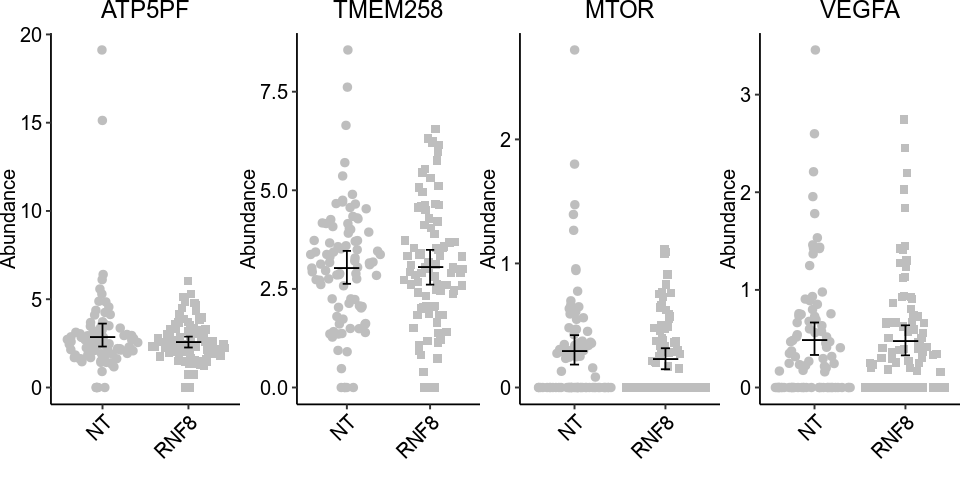

In [6]:
## RNF8 CRISPRi ##
wfix = 8
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/ATP5PF_df.rds')
goi = 'ATP5PF'
ATP5PF = ggplot(RNF8_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))


RNF8_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/TMEM258_df.rds')
goi = 'TMEM258'
TMEM258 = ggplot(RNF8_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))


RNF8_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MTOR_df.rds')
goi = 'MTOR'
MTOR = ggplot(RNF8_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))


RNF8_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/VEGFA_df.rds')
goi = 'VEGFA'
VEGFA = ggplot(RNF8_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(ATP5PF, TMEM258, MTOR, VEGFA, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig3/crispri_rnf8_single_cell_gene_examples.pdf'), width = wfix, height = hfix, device = cairo_pdf)

[1] "Percent genes with lower CV than control (top half): 72.63 %"

[1] "Percent genes with higher CV than control (bottom half): 27.37 %"

[1] "Mean CV (control): 1.09675060248231"

[1] "Mean CV (MIS18A): 0.926295894513471"

[1] "P-value paired t-test: 5.04e-208"

png 
  2

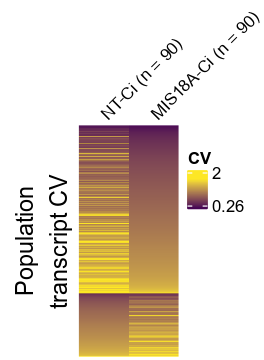

In [7]:
## MIS18A CRISPRi ##
wfix = 2.2
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

MIS18A_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ci_CV_htmp_df.rds')
lower_MIS18A = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ci_CV_lower.rds')
upper_MIS18A = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ci_CV_upper.rds')

set.seed(20)
coloring_map <- circlize::colorRamp2(c(0.24, 1.6), scales::viridis_pal(option = 'D')(5)[c(1,5)])

perturb_perturb_corr_mtx_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = TRUE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = 'Population\ntranscript CV', 
              row_title_side = 'left', column_title_side = 'top', column_names_side = 'top',
               column_names_gp = gpar(fontsize = 10), row_names_gp = gpar(fontsize = 1), column_names_rot = 45,
               cluster_rows = FALSE, cluster_columns = FALSE, heatmap_legend_param = list(title = "CV", at = c(0.26, 2))), padding = unit(c(2, 2, 2, 12), "pt"))
}


paste('Percent genes with lower CV than control (top half):', round(100*nrow(lower_MIS18A)/nrow(MIS18A_Ci_df), 2), '%')
paste('Percent genes with higher CV than control (bottom half):', round(100*nrow(upper_MIS18A)/nrow(MIS18A_Ci_df), 2), '%')
paste('Mean CV (control):', mean(MIS18A_Ci_df[,1]))
paste('Mean CV (MIS18A):', mean(MIS18A_Ci_df[,2]))
paste('P-value paired t-test:', signif(t.test(MIS18A_Ci_df[,1], MIS18A_Ci_df[,2], paired = TRUE)$p.value, 3))

perturb_perturb_corr_mtx_htmp(MIS18A_Ci_df)

pdf(paste0(path, 'fig_output/data/fig3/crispri_mis18a_single_cell_htmp_CVs_select.pdf'), width = wfix, height = hfix)
perturb_perturb_corr_mtx_htmp(MIS18A_Ci_df)
dev.off()

Warning message:
“`fun.y` is deprecated. Use `fun` instead.”


Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”


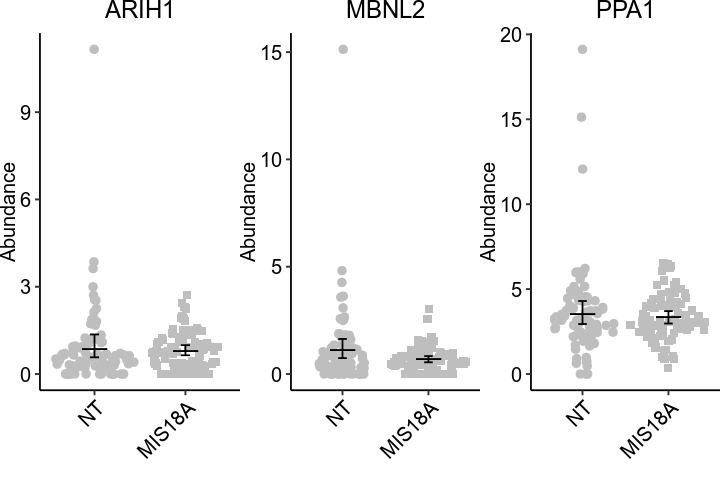

In [9]:
## MIS18A CRISPRi ##
wfix = 6
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)

MIS18A_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/ARIH1_df.rds')
goi = 'ARIH1'
ARIH1 = ggplot(MIS18A_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

MIS18A_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MBNL2_df.rds')
goi = 'MBNL2'
MBNL2 = ggplot(MIS18A_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

MIS18A_Ci_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/PPA1_df.rds')
goi = 'PPA1'
PPA1 = ggplot(MIS18A_Ci_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(ARIH1, MBNL2, PPA1, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig3/crispri_mis18a_single_cell_gene_examples.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### CRISPRa plots ###

[1] "Percent genes with lower CV than control (top half): 40.08 %"

[1] "Percent genes with higher CV than control (bottom half): 59.92 %"

[1] "Mean CV (control): 0.901789408992053"

[1] "Mean CV (RNF8): 0.940848966208527"

[1] "P-value paired t-test: 4.63e-57"

png 
  2

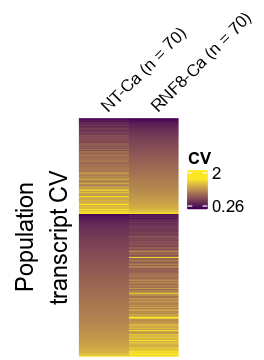

In [10]:
## RNF8 CRISPRa ##
wfix = 2.2
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ca_CV_htmp_df.rds')
lower_RNF8 = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ca_CV_lower.rds')
upper_RNF8 = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RNF8_Ca_CV_upper.rds')

set.seed(20)
coloring_map <- circlize::colorRamp2(c(0.26, 1.6), scales::viridis_pal(option = 'D')(5)[c(1,5)])

perturb_perturb_corr_mtx_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = TRUE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = 'Population\ntranscript CV', 
              row_title_side = 'left', column_title_side = 'top', column_names_side = 'top',
               column_names_gp = gpar(fontsize = 10), row_names_gp = gpar(fontsize = 1), column_names_rot = 45,
               cluster_rows = FALSE, cluster_columns = FALSE, heatmap_legend_param = list(title = "CV", at = c(0.26, 2))), padding = unit(c(2, 2, 2, 12), "pt"))
}



paste('Percent genes with lower CV than control (top half):', round(100*nrow(lower_RNF8)/nrow(RNF8_Ca_df), 2), '%')
paste('Percent genes with higher CV than control (bottom half):', round(100*nrow(upper_RNF8)/nrow(RNF8_Ca_df), 2), '%')
paste('Mean CV (control):', mean(RNF8_Ca_df[,1]))
paste('Mean CV (RNF8):', mean(RNF8_Ca_df[,2]))
paste('P-value paired t-test:', signif(t.test(RNF8_Ca_df[,1], RNF8_Ca_df[,2], paired = TRUE)$p.value, 3))

perturb_perturb_corr_mtx_htmp(RNF8_Ca_df)

pdf(paste0(path, 'fig_output/data/fig3/crispra_rnf8_single_cell_htmp_CVs_select.pdf'), width = wfix, height = hfix)
perturb_perturb_corr_mtx_htmp(RNF8_Ca_df)
dev.off()

Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”


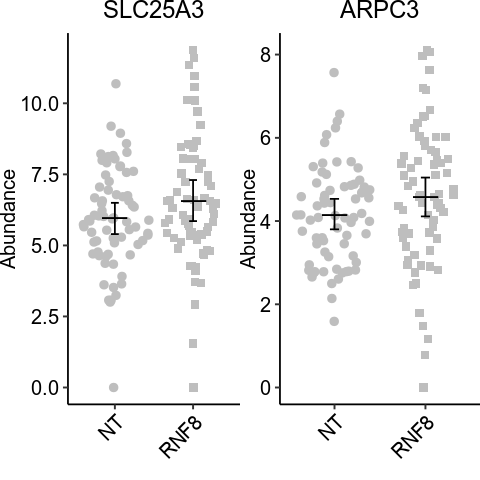

In [12]:
## RNF8 CRISPRa ##
wfix = 4
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)

RNF8_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/SLC25A3_df.rds')
goi = 'SLC25A3'
SLC25A3 = ggplot(RNF8_Ca_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

RNF8_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/ARPC3_df.rds')
goi = 'ARPC3'
ARPC3 = ggplot(RNF8_Ca_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(SLC25A3, ARPC3, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig3/crispra_rnf8_single_cell_gene_examples.pdf'), width = wfix, height = hfix, device = cairo_pdf)

[1] "Percent genes with lower CV than control (top half): 50.1 %"

[1] "Percent genes with higher CV than control (bottom half): 49.9 %"

[1] "Mean CV (control): 0.901789408992053"

[1] "Mean CV (MIS18A): 0.934693845063434"

[1] "P-value paired t-test: 1.38e-16"

png 
  2

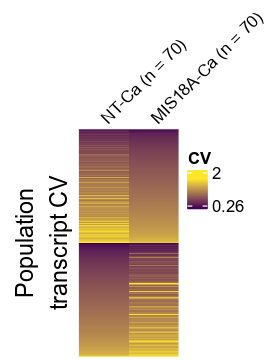

In [33]:
## MIS18A CRISPRa ##
wfix = 2.2
hfix = 3
options(repr.plot.width = wfix, repr.plot.height = hfix)

MIS18A_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ca_CV_htmp_df.rds')
lower_MIS18A = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ca_CV_lower.rds')
upper_MIS18A = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/MIS18A_Ca_CV_upper.rds')

set.seed(20)
coloring_map <- circlize::colorRamp2(c(0.26, 1.6), scales::viridis_pal(option = 'D')(5)[c(1,5)])

perturb_perturb_corr_mtx_htmp <- function(matrix, title) {
  draw(Heatmap(matrix, name = title, show_column_names = TRUE, show_row_names = FALSE, show_column_dend = FALSE,
               col = coloring_map, show_row_dend = FALSE, use_raster = TRUE, row_title = 'Population\ntranscript CV', 
              row_title_side = 'left', column_title_side = 'top', column_names_side = 'top',
               column_names_gp = gpar(fontsize = 10), row_names_gp = gpar(fontsize = 1), column_names_rot = 45,
               cluster_rows = FALSE, cluster_columns = FALSE, heatmap_legend_param = list(title = "CV", at = c(0.26, 2))), padding = unit(c(2, 2, 2, 12), "pt"))
}



paste('Percent genes with lower CV than control (top half):', round(100*nrow(lower_MIS18A)/nrow(MIS18A_Ca_df), 2), '%')
paste('Percent genes with higher CV than control (bottom half):', round(100*nrow(upper_MIS18A)/nrow(MIS18A_Ca_df), 2), '%')
paste('Mean CV (control):', mean(MIS18A_Ca_df[,1]))
paste('Mean CV (MIS18A):', mean(MIS18A_Ca_df[,2]))
paste('P-value paired t-test:', signif(t.test(MIS18A_Ca_df[,1], MIS18A_Ca_df[,2], paired = TRUE)$p.value, 3))

perturb_perturb_corr_mtx_htmp(MIS18A_Ca_df)

pdf(paste0(path, 'fig_output/data/fig3/crispra_mis18a_single_cell_htmp_CVs_select.pdf'), width = wfix, height = hfix)
perturb_perturb_corr_mtx_htmp(MIS18A_Ca_df)
dev.off()

## complicated results
## more genes have lower CV than control but CV shift is lower in magnitude in these compared to those with higher CV than control

Warning message:
“`fun.y` is deprecated. Use `fun` instead.”
Warning message:
“`fun.y` is deprecated. Use `fun` instead.”


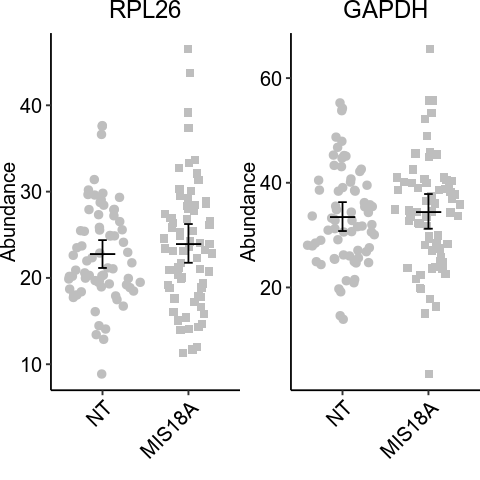

In [14]:
## MIS18A CRISPRa ##
wfix = 4
hfix = 4
options(repr.plot.width = wfix, repr.plot.height = hfix)

goi = 'RPL26'
MIS18A_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/RPL26_df.rds')
RPL26 = ggplot(MIS18A_Ca_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

goi = 'GAPDH'
MIS18A_Ca_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/GAPDH_df.rds')
GAPDH = ggplot(MIS18A_Ca_df, aes(guide, expression, shape = guide)) + geom_sina(size = 2, color = 'grey') + theme_pubr() + scale_shape_manual(values=c(19, 15)) +
stat_summary(fun.data = mean_cl_boot, geom = "errorbar", width = 0.1, fun.args=list(conf.int = 0.99)) + stat_summary(fun.y = mean, geom = "point", size = 5, shape = '\U2014') + #scale_y_continuous(trans='log10', breaks = c(1, 10^0.5, 10),labels = scales::trans_format("log10", scales::math_format(10^.x))) +
 theme(legend.position = 'none', plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + ylab('Abundance') + xlab('') + ggtitle(goi) +
 theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggarrange(RPL26, GAPDH, nrow = 1)

ggsave(paste0(path, 'fig_output/data/fig3/crispra_mis18a_single_cell_gene_examples.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### CRISPRi supplement ###

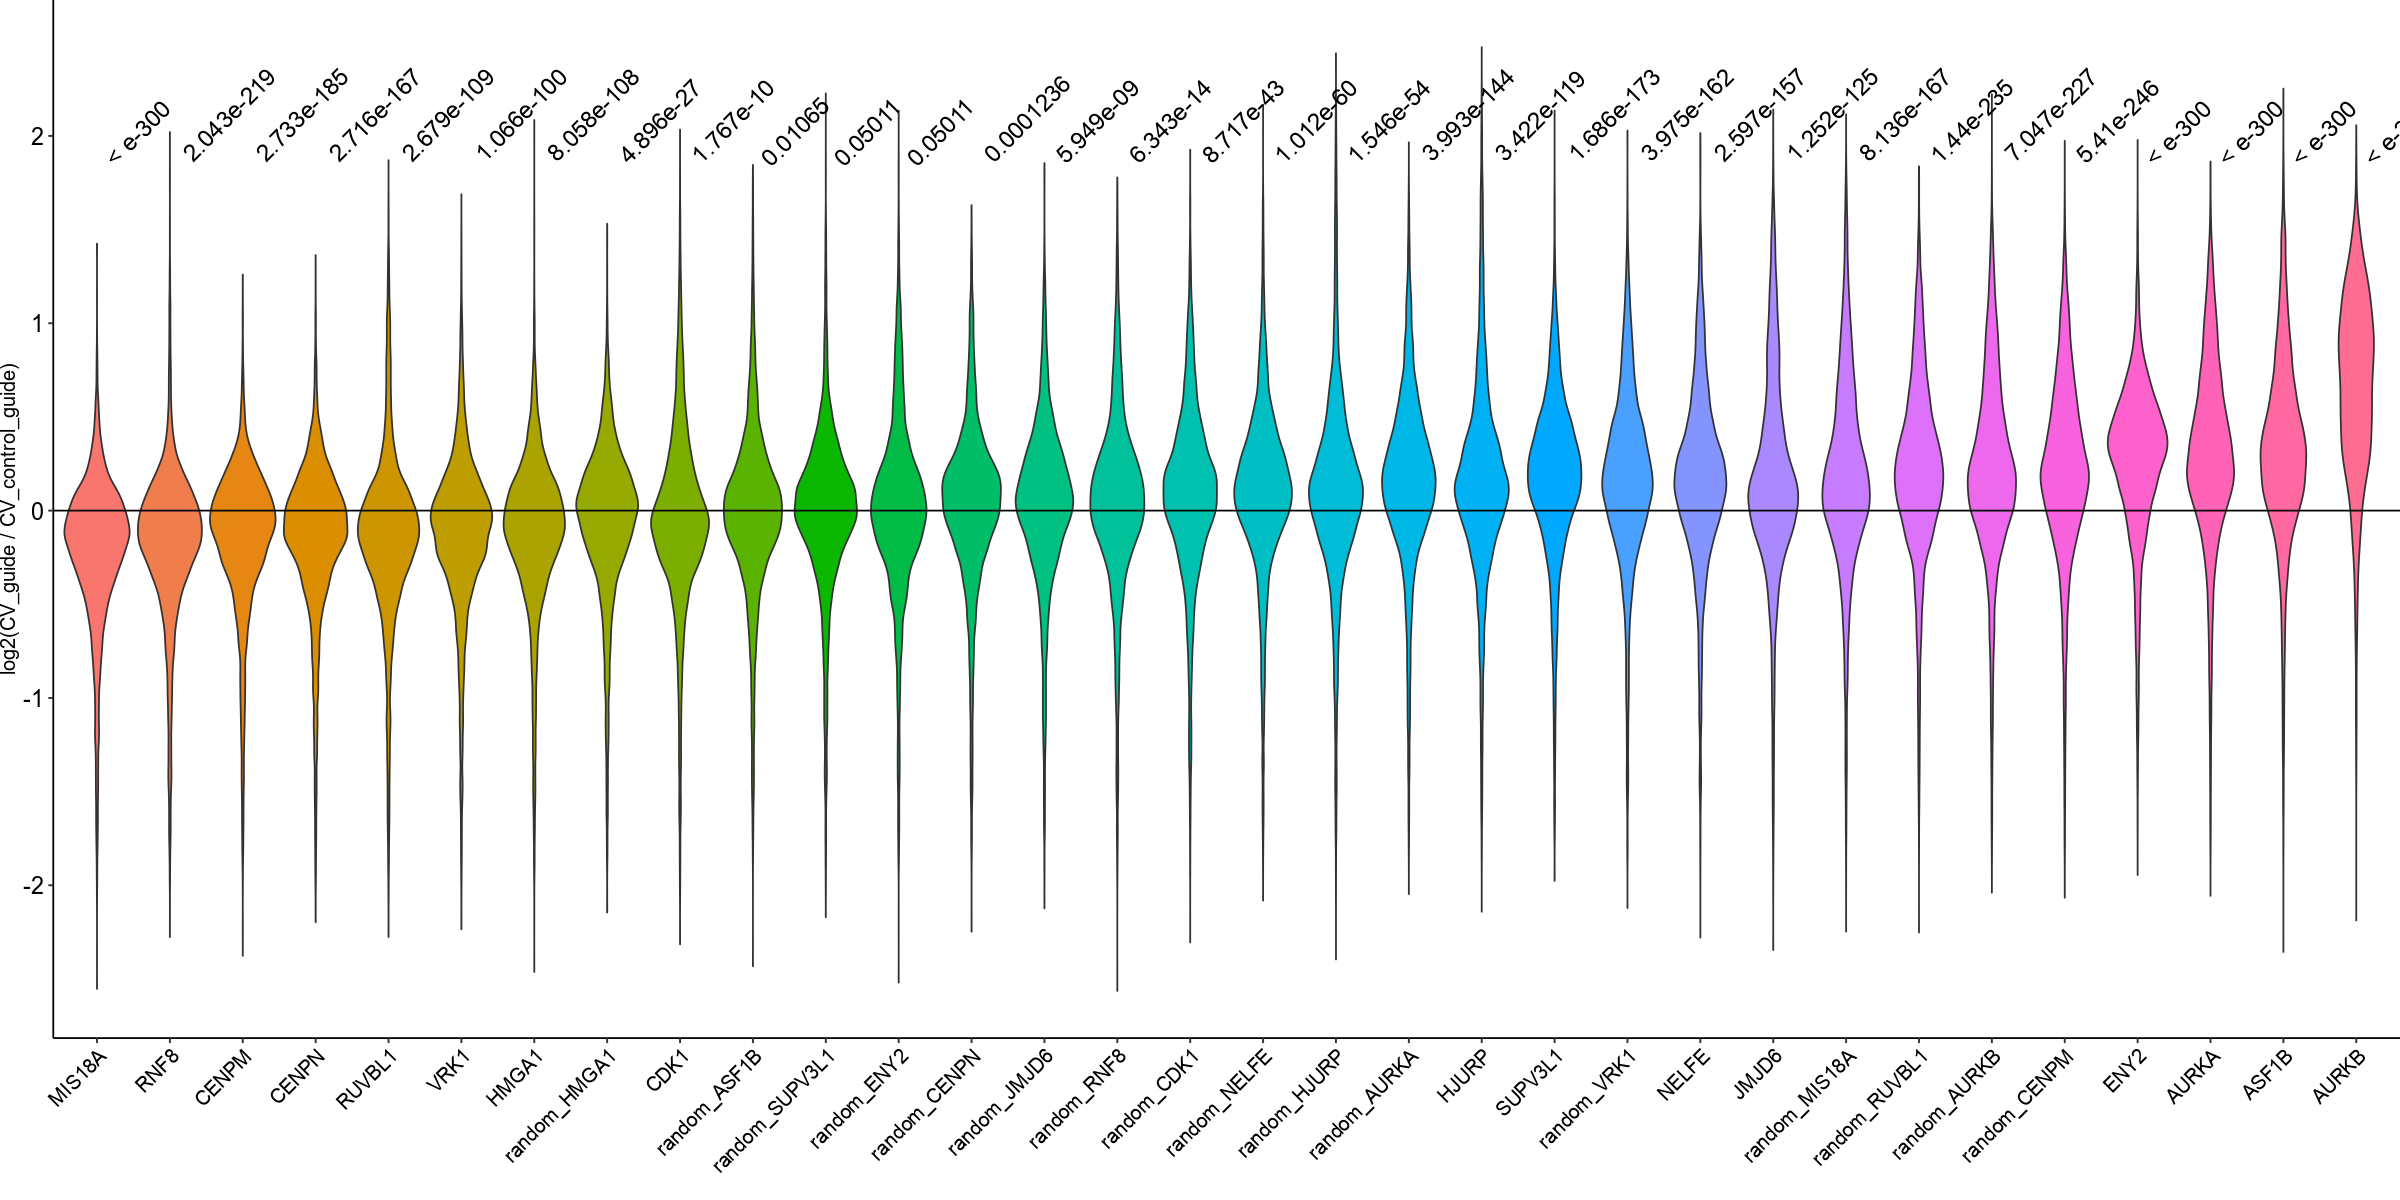

In [15]:
## CRISPRi ##
wfix = 20
hfix = 10
options(repr.plot.width = wfix, repr.plot.height = hfix)
ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_violin_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_pvals.rds')
plotted_guides = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_guides.rds')

ggplot(ratios_df, aes(guide, CV_gdCV_ctrlratio, fill = guide)) + ylab('log2(CV_guide / CV_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:length(plotted_guides), y = 1.8, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off') + xlab('') +
  theme_pubr() + theme(plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispri_single_cell_violin_CVs.pdf'), width = wfix, height = hfix, device = cairo_pdf)

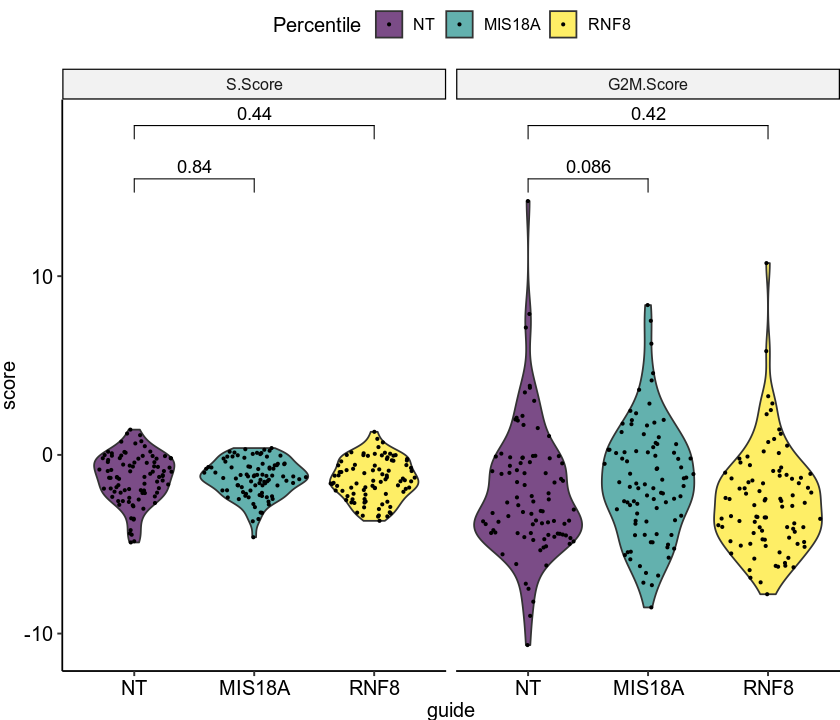

In [16]:
## CRISPRi ##
wfix = 7
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

cc_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_cc_df.rds')
cc_df %>% ggplot(aes(x = guide, y = score, fill = guide)) + geom_violin(position=position_dodge()) + 
  geom_sina(position=position_dodge(), size = 0.5) + scale_fill_viridis_d(alpha = 0.7, name = 'Percentile') +
  facet_wrap(~cycle) + stat_compare_means(comparisons = list(c('NT', 'MIS18A'), c('NT', 'RNF8')), method = 'wilcox.test') + theme_pubr() +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispri_single_cell_cc_violin.pdf'), width = wfix, height = hfix, device = cairo_pdf)


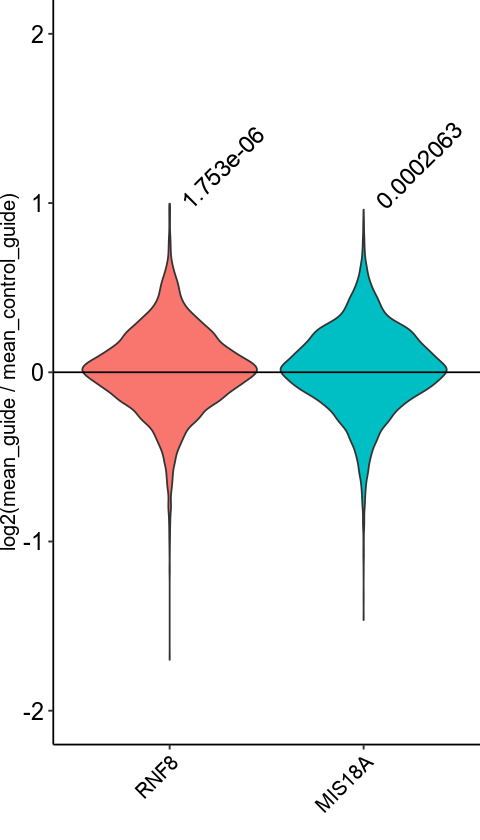

In [28]:
wfix = 4
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)

ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_violin_means_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_means_pvals.rds')
ratios = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_single_cell_violin_means_ratios.rds')

ratios_df %>% dplyr::filter(guide %in% c('MIS18A', 'RNF8')) %>% mutate(guide = factor(guide, levels = c('RNF8', 'MIS18A'))) %>% ggplot(aes(guide, mean_gdmean_ctrlratio, fill = guide)) + ylab('log2(mean_guide / mean_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:2, y = 0.9, size = 5, angle='45', hjust = -0.2, label = pvals_adj[names(ratios) %in% c('MIS18A', 'RNF8')][1:2]) +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off', ylim = c(-2,2)) + xlab('') +
  theme_pubr() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispri_single_cell_violin_means_select.pdf'), width = wfix, height = hfix, device = cairo_pdf)
  

### CRISPRa supplement ###

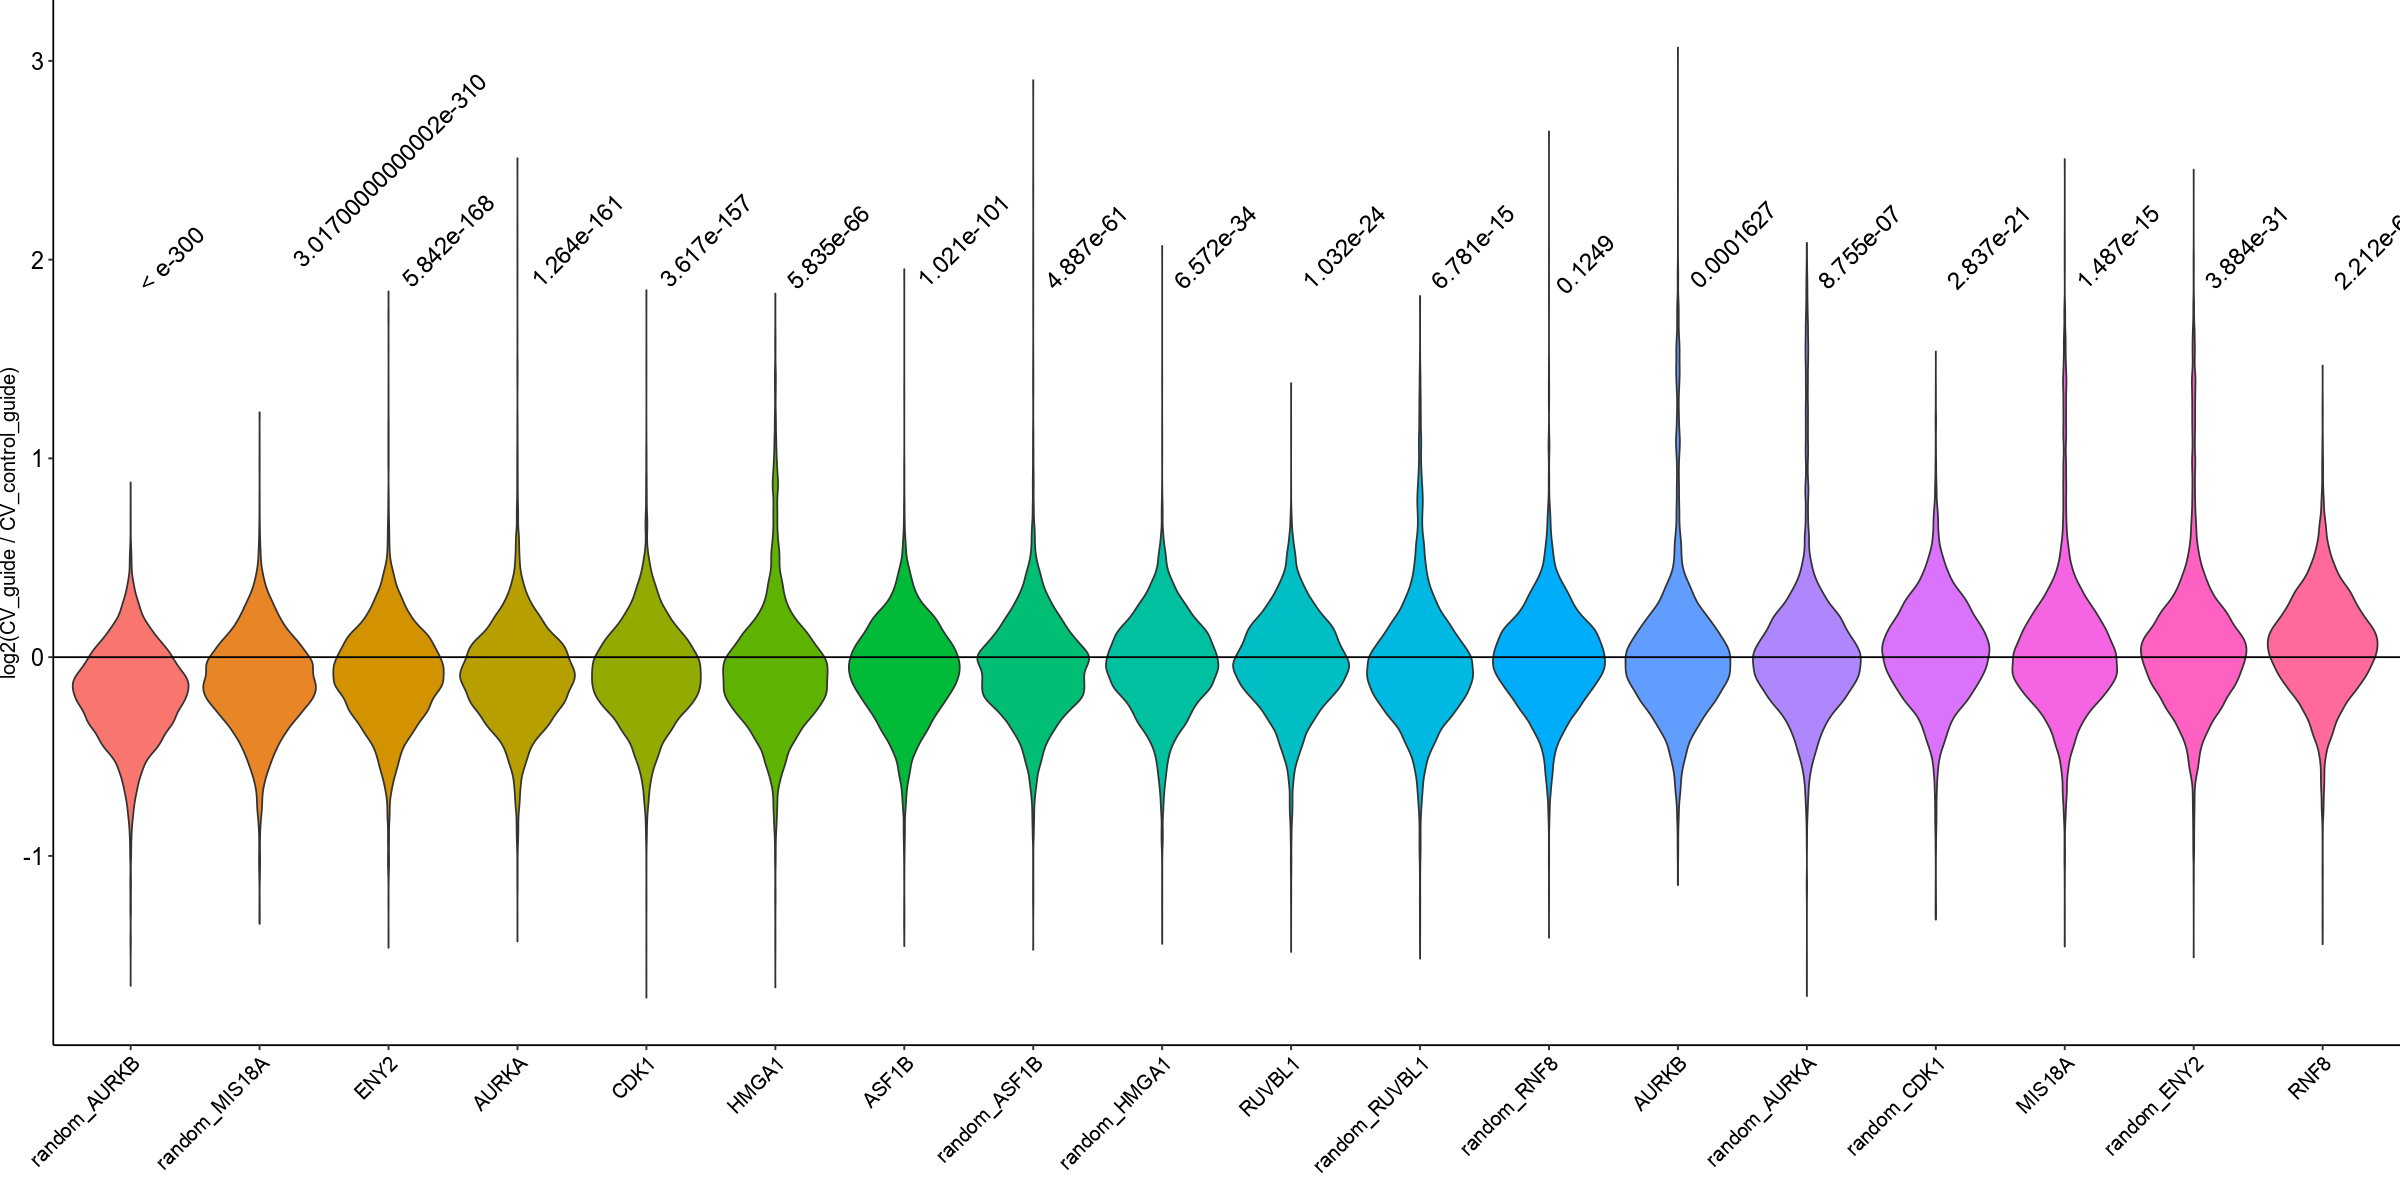

In [ ]:
## CRISPRa ##
wfix = 20
hfix = 10
options(repr.plot.width = wfix, repr.plot.height = hfix)
ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_violin_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_pvals.rds')
plotted_guides = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_guides.rds')

ggplot(ratios_df, aes(guide, CV_gdCV_ctrlratio, fill = guide)) + ylab('log2(CV_guide / CV_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:length(plotted_guides), y = 1.8, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off') + xlab('') +
  theme_pubr() + theme(plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispra_single_cell_violin_CVs.pdf'), width = wfix, height = hfix, device = cairo_pdf)

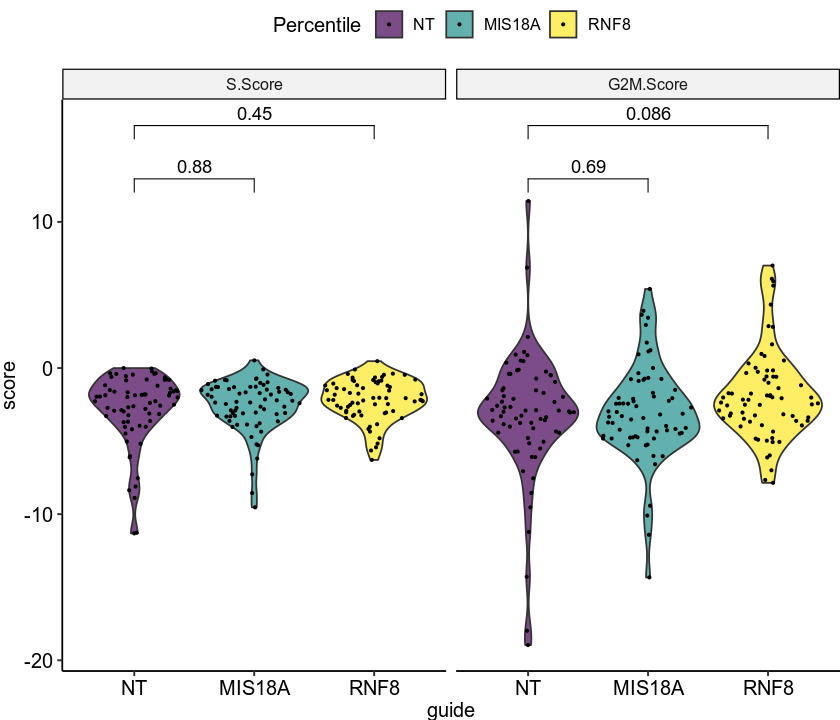

In [22]:
## CRISPRa ##
wfix = 7
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

cc_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_cc_df.rds')
cc_df %>% ggplot(aes(x = guide, y = score, fill = guide)) + geom_violin(position=position_dodge()) + 
  geom_sina(position=position_dodge(), size = 0.5) + scale_fill_viridis_d(alpha = 0.7, name = 'Percentile') +
  facet_wrap(~cycle) + stat_compare_means(comparisons = list(c('NT', 'MIS18A'), c('NT', 'RNF8')), method = 'wilcox.test') + theme_pubr() +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispra_single_cell_cc_violin.pdf'), width = wfix, height = hfix, device = cairo_pdf)

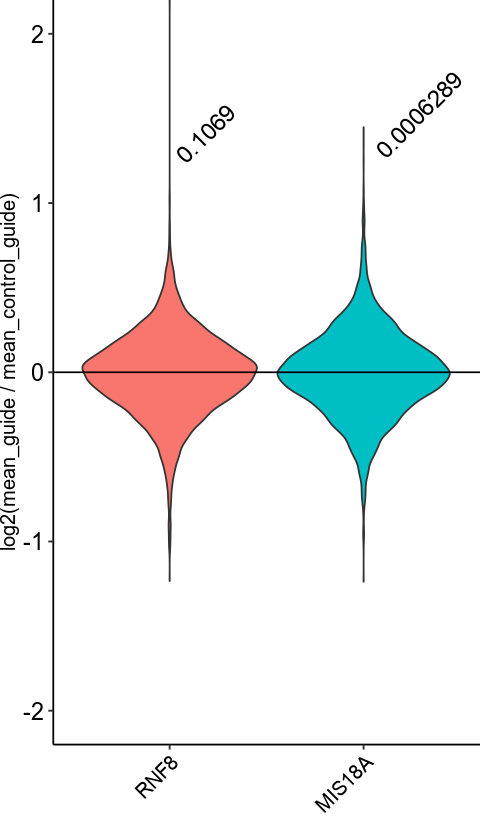

In [ ]:
wfix = 4
hfix = 7
options(repr.plot.width = wfix, repr.plot.height = hfix)

ratios_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_violin_means_df.rds')
pvals_adj = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_means_pvals.rds')
ratios = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_single_cell_violin_means_ratios.rds')

ratios_df %>% dplyr::filter(guide %in% c('MIS18A', 'RNF8')) %>% mutate(guide = factor(guide, levels = c('RNF8', 'MIS18A'))) %>% ggplot(aes(guide, mean_gdmean_ctrlratio, fill = guide)) + ylab('log2(mean_guide / mean_control_guide)') +
  geom_violin(position=position_dodge()) + annotate("text", x = 1:2, y = 1.2, size = 5, angle='45', hjust = -0.2, label = pvals_adj[names(ratios) %in% c('MIS18A', 'RNF8')][1:2]) +
  geom_hline(yintercept = 0) + coord_cartesian(clip = 'off', ylim = c(-2,2)) + xlab('') +
  theme_pubr() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/crispra_single_cell_violin_means_select.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### Qian et al single cell patient dataset ###

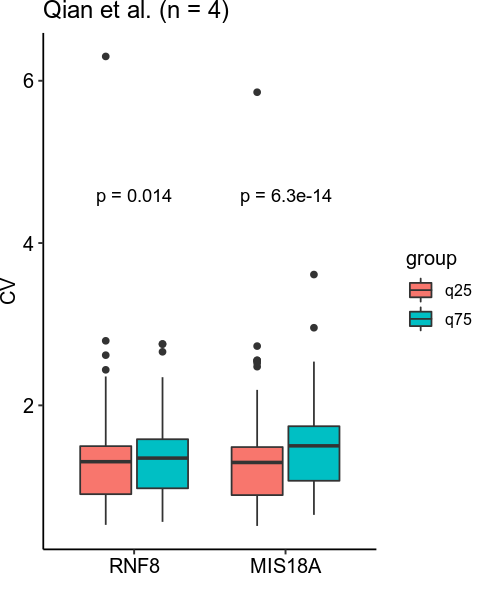

In [11]:
wfix = 4
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)

CVs_df = readRDS(paste0(path, 'fig_output/data/fig3/qian_CVs_df_q25_q75.rds'))
CVs_df$gene = factor(CVs_df$gene, levels = c('RNF8', 'MIS18A'))
## only kept genes with median normalized expression >= 0.1 ##
ggplot(CVs_df, aes(x = gene, y = CV, fill = group)) + geom_boxplot() + theme_pubr() + xlab('') + ggtitle('Qian et al. (n = 4)') + stat_compare_means(method = 'wilcox.test', label.y = 4.5, aes(label = paste0("p = ", after_stat(p.format)))) + theme(legend.position = "right") +
theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig3/qian_et_al_single_cell_CVs_boxplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

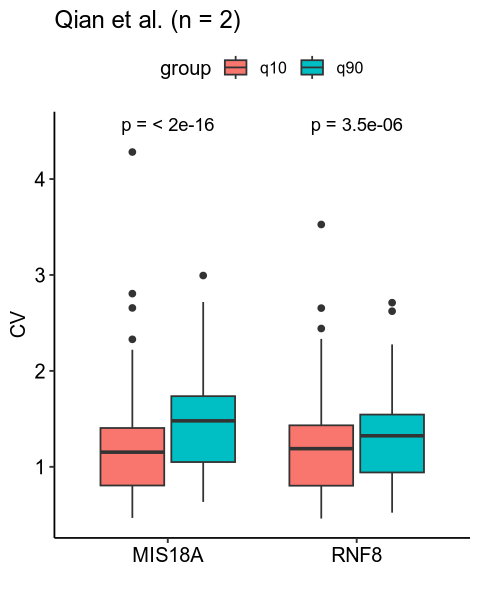

In [3]:
wfix = 4
hfix = 5
options(repr.plot.width = wfix, repr.plot.height = hfix)

CVs_df = readRDS(paste0(path, 'fig_output/data/fig3/qian_CVs_df_q10_q90.rds'))
## only kept genes with median normalized expression >= 0.1 ##
ggplot(CVs_df, aes(x = gene, y = CV, fill = group)) + geom_boxplot() + theme_pubr() + xlab('') + ggtitle('Qian et al. (n = 2)') + stat_compare_means(method = 'wilcox.test', label.y = 4.5, aes(label = paste0("p = ", after_stat(p.format)))) +
theme(margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

### CRISPRi knockdown efficiency ###

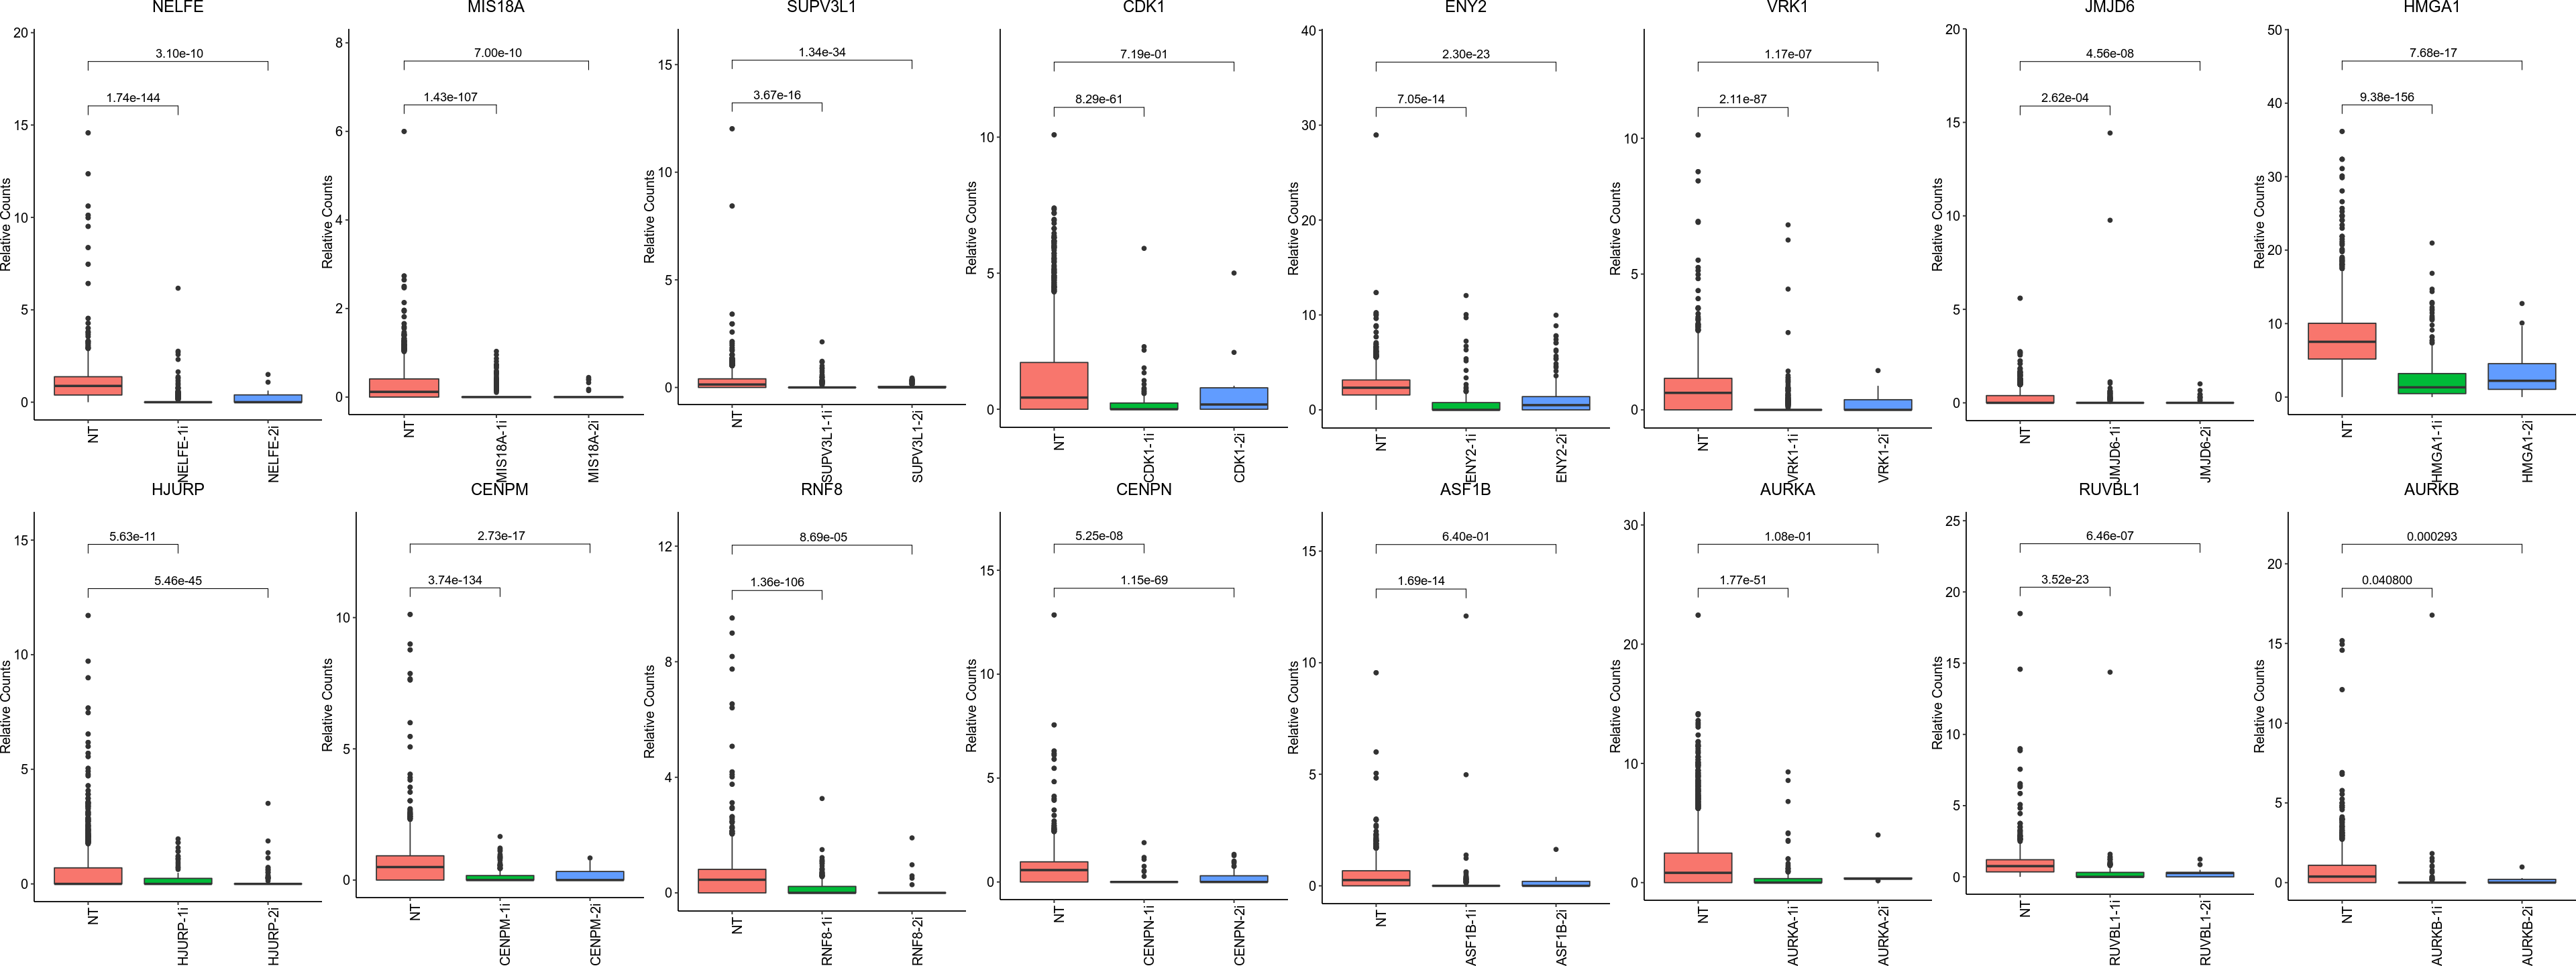

In [11]:
wfix = 32
hfix = 12
options(repr.plot.width = wfix, repr.plot.height = hfix)

exp_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispri_exp_df.rds')
genes = unique(exp_df$gene)
kd_plots = list()
## plot by guide
#options(repr.plot.width=15, repr.plot.height=7)
for (i in 1:length(genes)){
    df = exp_df %>% filter(gene == genes[i])
    guides = df %>% filter(guide != 'NT') %>% as.data.frame()
    guides = as.character(unique(guides$guide))
    upper_lim = max(as.data.frame(df %>% filter(gene == genes[i]))$exp)*1.1
    test1 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[1]))$exp)
    test2 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[2]))$exp)
    stat.test = data.frame(group1 = c('NT', 'NT'), group2 = c(guides[1], guides[2]), p = c(signif(test1$p.value, 3), signif(test2$p.value, 3)))
    stat.test = as.data.frame(apply(stat.test, 2, as.character))

    kd_plots[[i]] = df %>% ggplot(aes(x = guide, y = exp)) + geom_boxplot(aes(fill = guide)) + theme_pubr() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'),
    axis.title.x = element_blank(), legend.position = 'none') + 
    ggtitle(genes[i]) + stat_pvalue_manual(stat.test, label = 'p', y.position = upper_lim, step.increase = 0.15) + coord_cartesian(clip = 'off', ylim = c(0, upper_lim*1.2)) + ylab('Relative Counts') +
    theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))
}

ggarrange(plotlist = kd_plots, ncol = 8, nrow = 2)

ggsave(paste0(path, 'fig_output/data/fig3/crispri_knockdown_efficiency.pdf'), width = wfix, height = hfix, device = cairo_pdf)

Warning message in `[<-.factor`(`*tmp*`, iseq, value = "SUPV3L1-2a"):
“invalid factor level, NA generated”
Warning message in p.adjust(as.numeric(as.character(test$p)), method = "bonferroni"):
“NAs introduced by coercion”


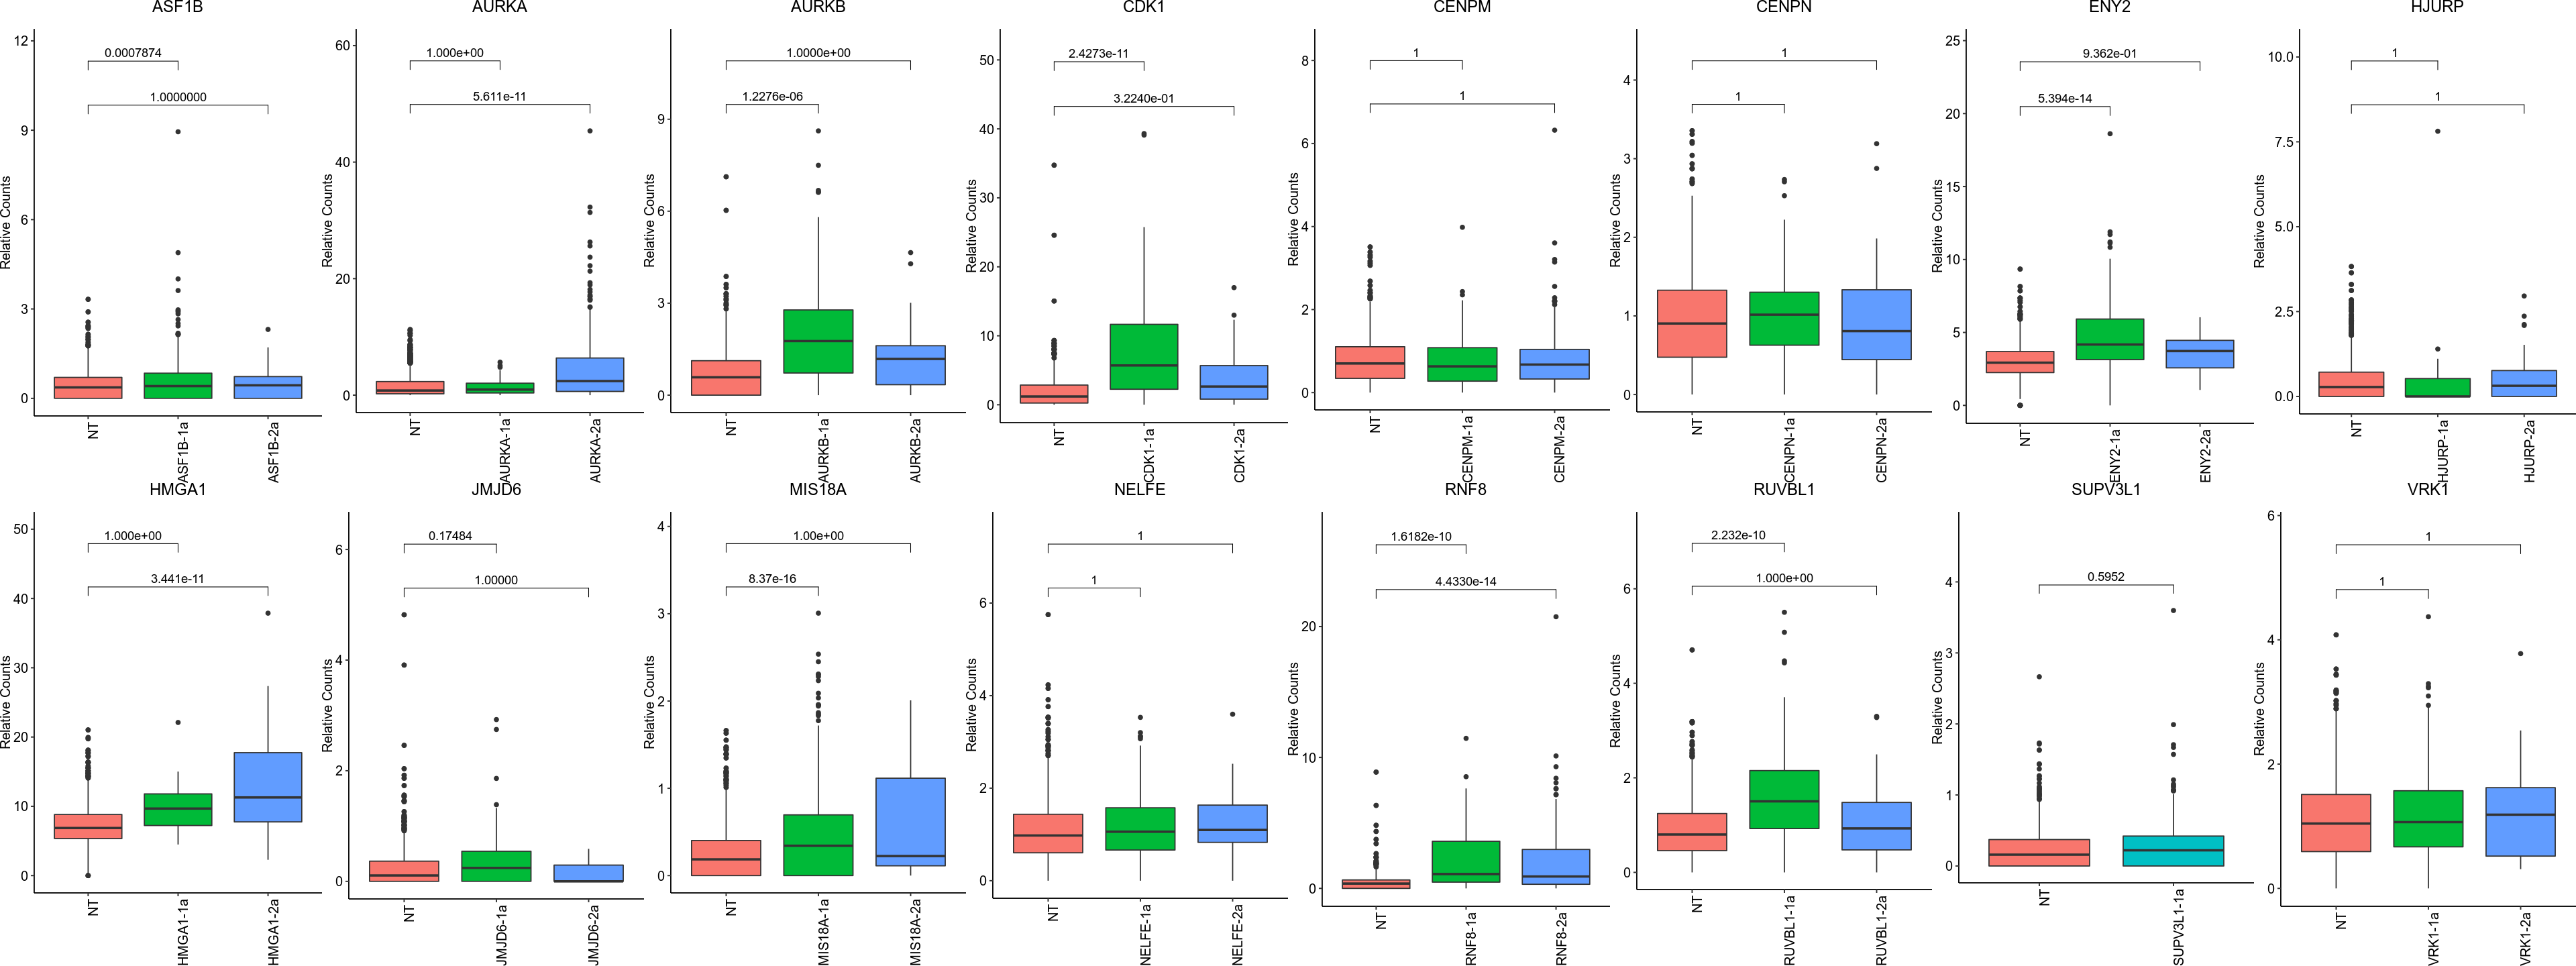

In [12]:
wfix = 32
hfix = 12
options(repr.plot.width = wfix, repr.plot.height = hfix)

exp_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig3/crispra_exp_df.rds')

## facet plot by guide and perform t-test between NT and each guide (p values are Bonferroni corrected !!)
genes = unique(exp_df$gene)
kd_plots = list()
test = list()
for (i in 1:length(genes)){
    df = exp_df %>% filter(gene == genes[i])
    guides = df %>% filter(guide != 'NT') %>% as.data.frame()
    guides = as.character(unique(guides$guide))
    if (length(guides) == 2){
        test1 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[1]))$exp)
        test2 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[2]))$exp)
        test[[i]] = data.frame(group1 = c('NT', 'NT'), group2 = c(guides[1], guides[2]), p = c(signif(test1$p.value, 3), signif(test2$p.value, 3)))
        test[[i]] = as.data.frame(apply(test[[i]], 2, as.character))
    }
    if (length(guides) == 1){
        test1 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[1]))$exp)
        test[[i]] = data.frame(group1 = c('NT'), group2 = c(guides[1]), p = c(signif(test1$p.value, 3)))
    }
}

test[genes == 'SUPV3L1'][[1]][2,] = c('NT', 'SUPV3L1-2a', 'NA')
test = do.call(rbind, test)
test = p.adjust(as.numeric(as.character(test$p)), method = 'bonferroni')

## plot by guide

for (i in 1:length(genes)){
    df = exp_df %>% filter(gene == genes[i])
    guides = df %>% filter(guide != 'NT') %>% as.data.frame()
    guides = as.character(unique(guides$guide))
    if (length(guides) == 2){
        upper_lim = max(as.data.frame(df %>% filter(gene == genes[i]))$exp)*1.1
        test1 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[1]))$exp)
        test2 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[2]))$exp)
        stat.test = data.frame(group1 = c('NT', 'NT'), group2 = c(guides[1], guides[2]), p = c(signif(test1$p.value, 3), signif(test2$p.value, 3)))
        stat.test$p = test[c(2*i-1, 2*i)]
        stat.test = as.data.frame(apply(stat.test, 2, as.character))

        kd_plots[[i]] = df %>% ggplot(aes(x = guide, y = exp)) + geom_boxplot(aes(fill = guide)) + theme_pubr() +
        theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'),
        axis.title.x = element_blank(), legend.position = 'none') + 
        ggtitle(genes[i]) + stat_pvalue_manual(stat.test, label = 'p', y.position = upper_lim, step.increase = 0.15) + coord_cartesian(clip = 'off', ylim = c(0, upper_lim*1.2)) + ylab('Relative Counts') +
        theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))
    }
    if (length(guides) == 1){
        upper_lim = max(as.data.frame(df %>% filter(gene == genes[i]))$exp)*1.1
        test1 = t.test(as.data.frame(df %>% filter(gene == genes[i] & guide == 'NT'))$exp, as.data.frame(df %>% filter(gene == genes[i] & guide == guides[1]))$exp)
        stat.test = data.frame(group1 = c('NT'), group2 = c(guides[1]), p = c(signif(test1$p.value, 3)))
        stat.test$p = test[2*i-1]

        kd_plots[[i]] = df %>% ggplot(aes(x = guide, y = exp)) + geom_boxplot(aes(fill = guide)) + theme_pubr() +
        theme(axis.text.x = element_text(angle = 90, hjust = 1), plot.title = element_text(hjust = 0.5, margin = margin(0,0,12,0)), plot.margin = unit(c(0.8, 0.5, 0.5, 0.5), 'cm'),
        axis.title.x = element_blank(), legend.position = 'none') + 
        ggtitle(genes[i]) + stat_pvalue_manual(stat.test, label = 'p', y.position = upper_lim, step.increase = 0.15) + coord_cartesian(clip = 'off', ylim = c(0, upper_lim*1.2)) + ylab('Relative Counts') +
        theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))
    }
}

kd_plots = kd_plots[order(genes)]
ggarrange(plotlist = kd_plots, ncol = 8, nrow = 2)
ggsave(paste0(path, 'fig_output/data/fig3/crispra_upregulation_efficiency.pdf'), width = wfix, height = hfix, device = cairo_pdf)

## Fig 4 ##


### cell paint morphology scores ###

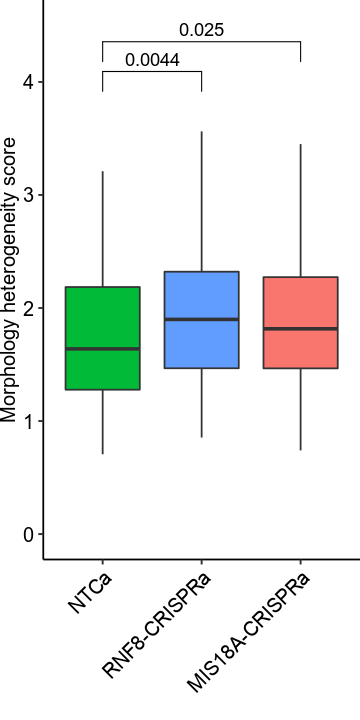

In [26]:
wfix = 3
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

dists = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_heterogeneity_scores.rds')
dists$sample_name = factor(dists$sample_name, levels = c('NTCi', 'NTCa', 'HMGA1-CRISPRi', 'MIS18A-CRISPRa', 'MIS18A-CRISPRi', 'RNF8-CRISPRa', 'RNF8-CRISPRi', 'RUVBL1-CRISPRi', 'VRK1-CRISPRi'))

samples = as.character(dists %>% pull(sample_name) %>% unique() %>% sort())
my_comparisons = list(c(samples[2], samples[4]), c(samples[2], samples[6]))
my_comparisons = lapply(my_comparisons, as.character)
upper_lim = max(dists %>% pull(distances))*1.05

plt1b = dists %>% filter(sample_name %in% c('NTCa', 'MIS18A-CRISPRa', 'RNF8-CRISPRa')) %>% mutate(sample_name = factor(sample_name, levels = c('NTCa', 'RNF8-CRISPRa', 'MIS18A-CRISPRa'))) %>% ggplot(aes(x=sample_name, y=distances, fill=sample_name)) + theme_pubr() + xlab('') + coord_cartesian(ylim = c(0, 4.5)) + stat_compare_means(method = "wilcox.test", comparisons = rev(my_comparisons), label.y = 3.8, step.increase = 0.045, method.args = list(alternative = "less")) +
  geom_boxplot(show.legend = FALSE, outlier.shape = NA) + ylab('Morphology heterogeneity score') + theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plt1b
ggsave(paste0(path, 'fig_output/data/fig4/crispra_morphology_scores.pdf'), width = wfix, height = hfix, device = cairo_pdf)

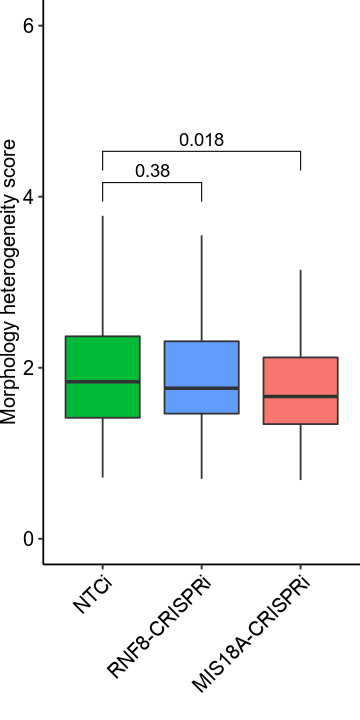

In [25]:
wfix = 3
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

dists = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_boxplots_df.rds')
my_comparisons = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_boxplots_df_crispri_select_comparisons.rds')

plt1a = dists %>% filter(sample_name %in% c('NTCi', 'MIS18A-CRISPRi', 'RNF8-CRISPRi')) %>% mutate(sample_name = factor(sample_name, levels = c('NTCi', 'RNF8-CRISPRi', 'MIS18A-CRISPRi'))) %>% ggplot(aes(x=sample_name, y=distances, fill=sample_name)) + theme_pubr() + xlab('') + coord_cartesian(ylim = c(0,6)) + stat_compare_means(method = "wilcox.test", comparisons = rev(my_comparisons), label.y = 3.8, step.increase = 0.05, method.args = list(alternative = "greater")) +
  geom_boxplot(show.legend = FALSE, outlier.shape = NA) + ylab('Morphology heterogeneity score') + theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plt1a
ggsave(paste0(path, 'fig_output/data/fig4/crispri_morphology_scores.pdf'), width = wfix, height = hfix, device = cairo_pdf)

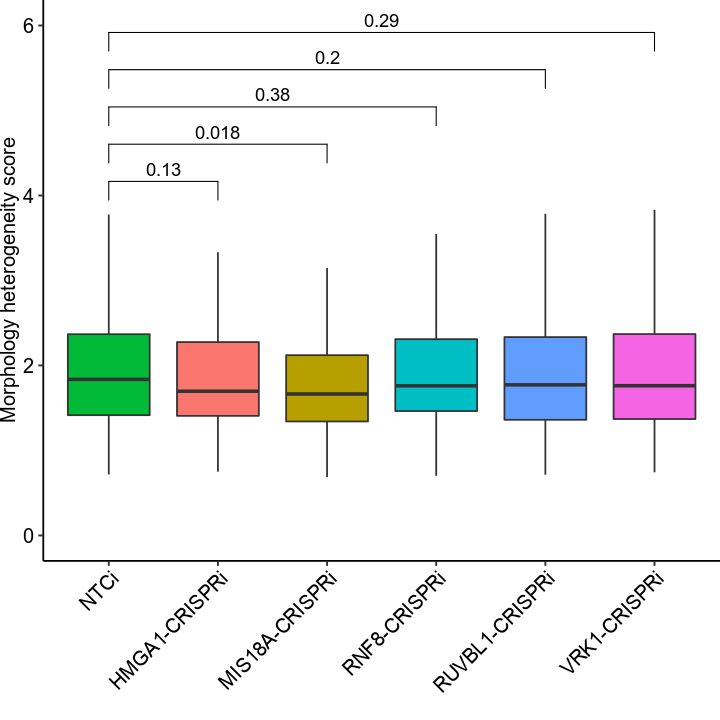

In [11]:
wfix = 6
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

dists = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_boxplots_df.rds')
my_comparisons = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_boxplots_df_crispri_comparisons.rds')

plt1a = dists %>% filter(endsWith(as.character(sample_name), 'i')) %>% ggplot(aes(x=sample_name, y=distances, fill=sample_name)) + theme_pubr() + xlab('') + coord_cartesian(ylim = c(0,6)) + stat_compare_means(method = "wilcox.test", comparisons = my_comparisons, label.y = 3.8, step.increase = 0.06, method.args = list(alternative = "greater")) +
  geom_boxplot(show.legend = FALSE, outlier.shape = NA) + ylab('Morphology heterogeneity score') + theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plt1a
ggsave(paste0(path, 'fig_output/data/fig4/crispri_morphology_scores_all.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### supplementary figs ###

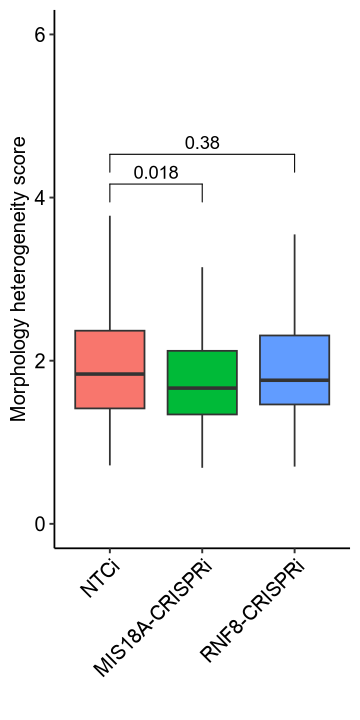

In [5]:
## cell paint morphology scores ##

wfix = 3
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)
## expected height in illustrator is 2.5
scale_factor = hfix/2.5 ## always divide height by height -- much less likely to change to make figure look better

dists = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_heterogeneity_scores.rds')

dists$sample_name = factor(dists$sample_name, levels = c('NTCi', 'NTCa', 'HMGA1-CRISPRi', 'MIS18A-CRISPRa', 'MIS18A-CRISPRi', 'RNF8-CRISPRa', 'RNF8-CRISPRi', 'RUVBL1-CRISPRi', 'VRK1-CRISPRi'))
#saveRDS(dists, '/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig4/morphology_heterogeneity_scores.rds')
samples = dists %>% pull(sample_name) %>% unique() %>% sort()
my_comparisons = list(c(samples[1], samples[5]), c(samples[1], samples[7]))
my_comparisons = lapply(my_comparisons, as.character)
upper_lim = max(dists %>% pull(distances))*1.05

plt1a = dists %>% filter(sample_name %in% c('NTCi', 'MIS18A-CRISPRi', 'RNF8-CRISPRi')) %>% ggplot(aes(x=sample_name, y=distances, fill=sample_name)) + theme_pubr() + xlab('') + coord_cartesian(ylim = c(0,6)) + stat_compare_means(method = "wilcox.test", comparisons = my_comparisons, label.y = 3.8, step.increase = 0.05, method.args = list(alternative = "greater")) +
  geom_boxplot(show.legend = FALSE, outlier.shape = NA) + ylab('Morphology heterogeneity score') + theme(plot.title = element_text(hjust = 0.5), axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) +
  theme(margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

plt1a
ggsave(paste0(path, 'fig_output/data/fig4/crispri_morphology_scores.pdf'), width = wfix, height = hfix)

## Fig 6 ##


### scATAC-seq violin plots ###

Warning message:
“Removed 21 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 21 rows containing non-finite values (stat_signif).”
Warning message:
“Removed 21 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 21 rows containing non-finite values (stat_signif).”


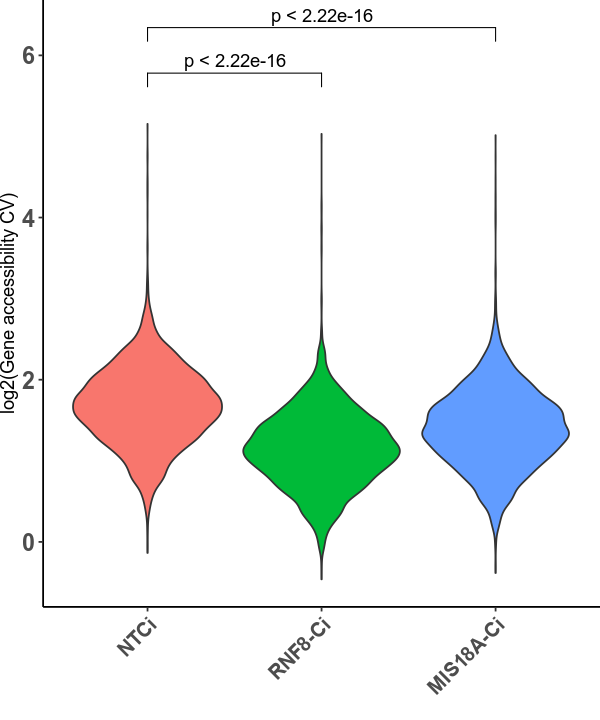

In [ ]:
### CRISPRi ###
wfix = 5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

CVs_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/CVs_CRISPRi_violin_df.rds')

comparisons = list(c('NTCi', 'RNF8-Ci'), c('NTCi', 'MIS18A-Ci'))
ggplot(CVs_df, aes(guide, CV_gd)) + ylab('log2(Gene accessibility CV)') + xlab('') +
  geom_violin(aes(fill = guide), position=position_dodge()) + #annotate("text", x = 1:length(plotted_guides), y = 3.5, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  coord_cartesian(clip = 'off') + stat_compare_means(comparisons = comparisons, method = 'wilcox.test', label.y = 5.5, na.rm = T, step.increase = 0.1) + 
  theme_classic() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(face = 'bold', size = 14), axis.text.x = element_text(face = 'bold', size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig6/crispri_scatac_violin.pdf'), width = wfix, height = hfix, device = cairo_pdf)

Warning message:
“Removed 24 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 24 rows containing non-finite values (stat_signif).”
Warning message:
“Removed 24 rows containing non-finite values (stat_ydensity).”
Warning message:
“Removed 24 rows containing non-finite values (stat_signif).”


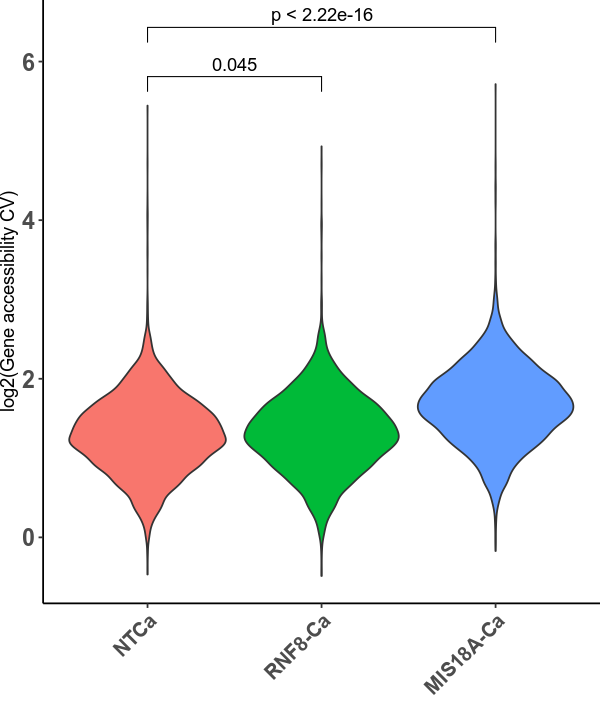

In [13]:
### CRISPRa ###
wfix = 5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

CVs_df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/CVs_CRISPRa_violin_df.rds')

comparisons = list(c('NTCa', 'RNF8-Ca'), c('NTCa', 'MIS18A-Ca'))
ggplot(CVs_df, aes(guide, CV_gd)) + ylab('log2(Gene accessibility CV)') + xlab('') +
  geom_violin(aes(fill = guide), position=position_dodge()) + #annotate("text", x = 1:length(plotted_guides), y = 3.5, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  coord_cartesian(clip = 'off') + stat_compare_means(comparisons = comparisons, method = 'wilcox.test', label.y = 5.5, na.rm = T, step.increase = 0.1) + 
  theme_classic() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(face = 'bold', size = 14), axis.text.x = element_text(face = 'bold', size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig6/crispra_scatac_violin.pdf'), width = wfix, height = hfix, device = cairo_pdf)

### scATAC-seq track CV plots ###

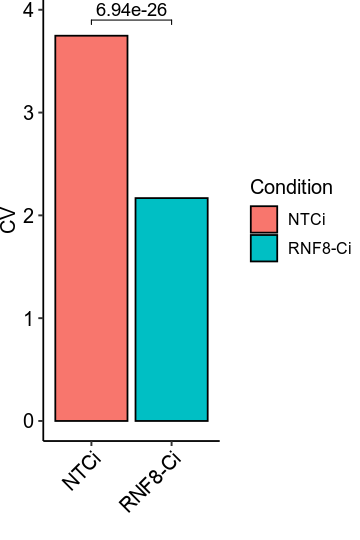

In [2]:
wfix = 3
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/NR3C2_rnf8_ci_track_barplot_df.rds')
stat.test = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/NR3C2_rnf8_ci_track_barplot_test.rds')
stat.test$p.adj = signif(stat.test$p.adj, digits = 3)

ggplot(df, aes(y = CV, x = Condition, fill = Condition)) + 
    geom_bar(color = 'black', stat = "identity", show.legend = T) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', tip.length = 0.025, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('CV') + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig6/NR3C2_rnf8_ci_track_barplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

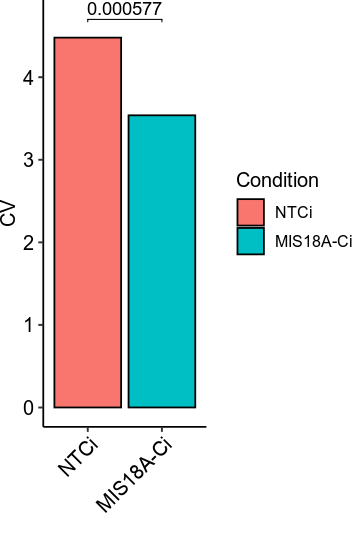

In [3]:
wfix = 3
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/TMEM248_MIS18A_ci_track_barplot_df.rds')
stat.test = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/TMEM248_MIS18A_ci_track_barplot_test.rds')
stat.test$p.adj = signif(stat.test$p.adj, digits = 3)

ggplot(df, aes(fill = Condition, y = CV, x = Condition)) + 
    geom_bar(color = 'black', stat = "identity", show.legend = T) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', tip.length = 0.025, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('CV') + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig6/TMEM248_MIS18A_ci_track_barplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

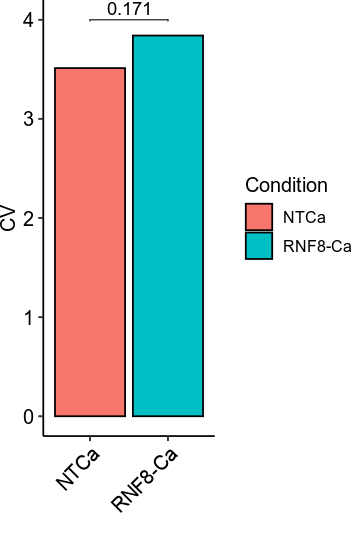

In [4]:
wfix = 3
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/TRPS1_rnf8_ca_track_barplot_df.rds')
stat.test = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/TRPS1_rnf8_ca_track_barplot_test.rds')
stat.test$p.adj = signif(stat.test$p.adj, digits = 3)
stat.test$y.position = 4

ggplot(df, aes(fill = Condition, y = CV, x = Condition)) + 
    geom_bar(color = 'black', stat = "identity", show.legend = T) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', tip.length = 0.025, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('CV') + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig6/TRPS1_rnf8_ca_track_barplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

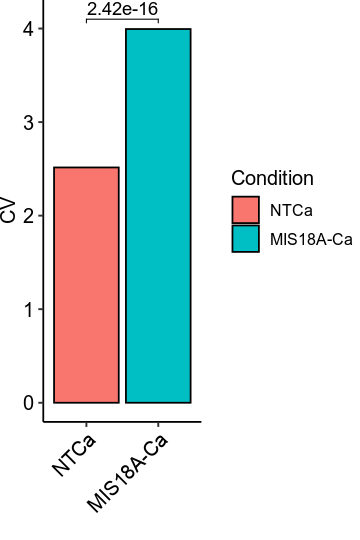

In [5]:
wfix = 3
hfix = 4.5
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/PPP4R2_MIS18A_ca_track_barplot_df.rds')
stat.test = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/PPP4R2_MIS18A_ca_track_barplot_test.rds')
stat.test$p.adj = signif(stat.test$p.adj, digits = 3)

ggplot(df, aes(fill = Condition, y = CV, x = Condition)) + 
    geom_bar(color = 'black', stat = "identity", show.legend = T) + theme_pubr() + stat_pvalue_manual(stat.test, label = 'p.adj', tip.length = 0.025, inherit.aes = F) +
    theme(legend.position = "right", axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) + xlab('') + ylab('CV') + 
    theme(plot.margin = unit(c(0, 0, 0, 0), "in"), plot.title = element_text(hjust = 0.5, family = "Helvetica"), axis.text.x = element_text(family = "Helvetica"), axis.title = element_text(family = "Helvetica"), legend.text = element_text(family = "Helvetica"), legend.title = element_text(family = "Helvetica"))

ggsave(paste0(path, 'fig_output/data/fig6/PPP4R2_MIS18A_ca_track_barplot.pdf'), width = wfix, height = hfix, device = cairo_pdf)

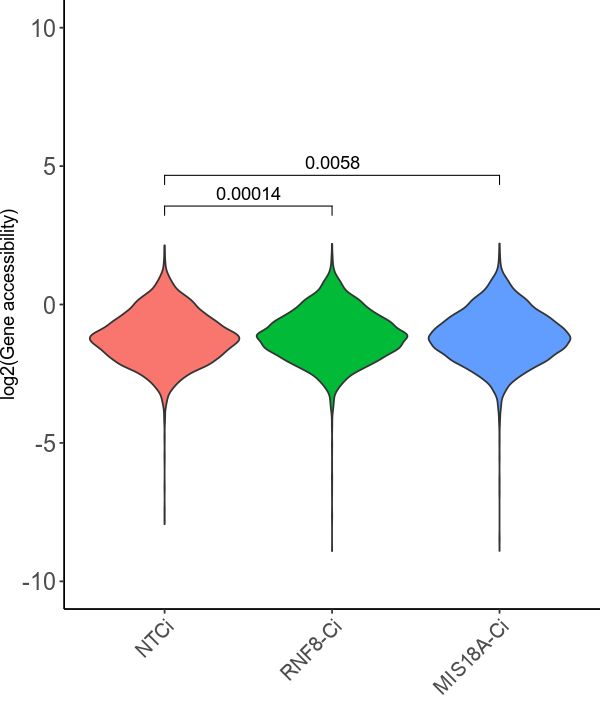

In [12]:
wfix = 5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/means_CRISPRi_violin_df.rds')
## This shows there is more global gene accessibility in the RNF8-Ci and MIS18A-Ci guides than NTCi guide which is weird...

options(repr.plot.width = 5, repr.plot.height = 6)
library(ggforce)
#plotted_guides = names(master_df_list)[!(names(master_df_list) %in% c('random_NTCi'))]
comparisons = list(c('NTCi', 'RNF8-Ci'), c('NTCi', 'MIS18A-Ci'))
ggplot(df, aes(guide, values)) + ylab('log2(Gene accessibility)') + xlab('') +
  geom_violin(aes(fill = guide), position=position_dodge()) + #annotate("text", x = 1:length(plotted_guides), y = 3.5, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  coord_cartesian(clip = 'off') + ylim(-10, 10) + stat_compare_means(comparisons = comparisons, method = 't.test', label.y = 3, na.rm = T, step.increase = 0.1) + 
  theme_classic() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig6/crispri_scatac_violin_means.pdf'), width = wfix, height = hfix, device = cairo_pdf)

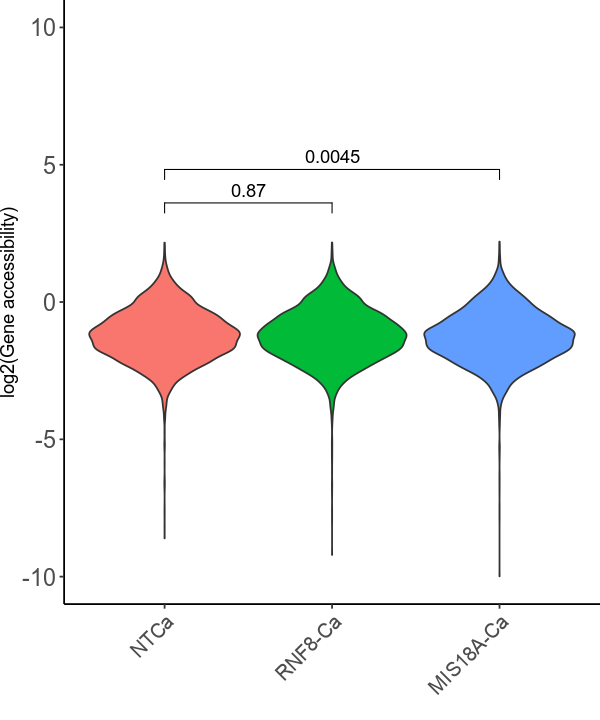

In [13]:
wfix = 5
hfix = 6
options(repr.plot.width = wfix, repr.plot.height = hfix)

df = readRDS('/home/ssobti/projects/heterogeneity_brian/fig_output/data/fig6/means_CRISPRa_violin_df.rds')
## This shows there is less global gene accessibility in the MIS18A-Ca guide compared to NTCa, RNF8-Ca and NTCa are equivalent

#plotted_guides = names(master_df_list)[!(names(master_df_list) %in% c('random_NTCa'))]
comparisons = list(c('NTCa', 'RNF8-Ca'), c('NTCa', 'MIS18A-Ca'))
ggplot(df, aes(guide, values)) + ylab('log2(Gene accessibility)') + xlab('') +
  geom_violin(aes(fill = guide), position=position_dodge()) + #annotate("text", x = 1:length(plotted_guides), y = 3.5, size = 5, angle='45', hjust = -0.2, label = pvals_adj) +
  coord_cartesian(clip = 'off') + ylim(-10, 10) + stat_compare_means(comparisons = comparisons, method = 't.test', label.y = 3, na.rm = T, step.increase = 0.1) + 
  theme_classic() + theme(plot.margin = margin(1,1,1,1, "cm"), plot.title = element_text(hjust = 0.5), legend.position = 'none', axis.text.y = element_text(size = 14), axis.text.x = element_text(size = 12, angle = 45, hjust = 1)) +
  theme(plot.margin = margin(0,0,0,0, unit = "cm"), axis.text = element_text(family = "Arial"), axis.title = element_text(family = "Arial"), legend.text = element_text(family = "Arial"), legend.title = element_text(family = "Arial"))

ggsave(paste0(path, 'fig_output/data/fig6/crispra_scatac_violin_means.pdf'), width = wfix, height = hfix, device = cairo_pdf)